(mmm_funnel_mueffect_advanced)=
# Advanced Funnel-Aware MMM: Geo-Level Mediation with Multiple Demand Proxies

The {ref}`mmm_funnel_mueffect` notebook introduced the core idea: upper-funnel
activity creates demand that shows up later in lower-funnel channels, and we can
encode that mediation directly in `pymc-marketing` through a custom
{class}`~pymc_marketing.mmm.additive_effect.MuEffect` carrying its own likelihood.
That example kept the funnel deliberately minimal -- one upper channel, one
mediator, one national time series.

Real engagements are not that tidy. This notebook scales the same idea up to a
setup that looks much more like production work:

1. **Several upper-funnel channels** feed the same latent demand pool, each with
   its own carryover and saturation.
2. **A geo panel**: the model is fit across regions at once, with some parameters
   pooled across geos and others estimated per geo.
3. **Two noisy proxies for latent demand** -- lower-funnel spend *and* branded
   search volume -- instead of a single mediator, which is what actually pins down
   the mediator equation.
4. **Seasonal confounding**: category demand is seasonal, media plans follow that
   seasonality, and the target has its own seasonality on top.

Along the way we use two pieces of the library that make this much less painful
than hand-rolling everything:

- {class}`~pymc_marketing.mmm.additive_effect.DataVarMuEffect`, which reads the
  effect's data straight out of the training `xarray` dataset, so we only write
  the part of the effect that is genuinely custom.
- `pymc.dims` **xtensors**, whose named broadcasting lets a `("geo",)` parameter,
  a `("channel",)` parameter and a `("date", "geo", "channel")` data array combine
  without a single `reshape` or `None`-index.

```{note}
This is a self-contained methodological example built on fully synthetic data. It
does not reference any specific client or engagement.
```

## The funnel structure

We model a weekly geo panel. Within every geo $g$ and week $t$:

- `tv_spend`, `social_spend` ($U_{t,g,c}$): two **upper-funnel** channels.
- `category_demand` ($C_{t,g}$): an exogenous, seasonal index of how much the
  whole category is in-market (think a category-level search-trend index). It
  drives lower-funnel demand but does **not** act on the target directly -- an
  **exclusion restriction** on the mediator equation.
- $D_{t,g}$: the **latent** lower-funnel demand. Never observed.
- `lower_spend` ($M_{t,g}$) and `search_volume` ($S_{t,g}$): two **observed,
  noisy proxies** of that latent demand.
- `y` ($Y_{t,g}$): the target.

The mediator equation aggregates both upper channels into one demand pool:

$$
D_{t,g} = \text{baseline}_g + \gamma_g\, C_{t,g}
          + \sum_{c} \text{sat}^{uf}\!\left(\text{adstock}^{uf}(U_{t,g,c})\right).
$$

The two proxies are **measurements** of $D$, each with its own noise:

$$
M_{t,g} \sim \text{TruncatedNormal}(D_{t,g},\, \sigma^M_g,\, \text{lower}=0),
\qquad
S_{t,g} \sim \text{Normal}(\kappa\, D_{t,g},\, \sigma^S_g).
$$

Note the asymmetry: $M$'s loading on $D$ is **fixed at one** while $S$'s loading
$\kappa$ is free. This is the standard normalization in a factor model -- a latent
variable has no natural scale, so we anchor it to one of its indicators and let
the others find their own scale relative to it. Without such a constraint
$D \to 2D$, $\kappa \to \kappa/2$ would be observationally identical.

Finally the target responds to the **latent demand**, plus the direct effect of
each upper channel and its own seasonality:

$$
Y_{t,g} = \text{intercept}_g
        + \sum_c \text{sat}\!\left(\text{adstock}(U_{t,g,c})\right)
        + \text{Fourier}(t)\cdot\gamma^{F}_g
        + \text{sat}^{lf}\!\left(\text{adstock}^{lf}(D_{t,g})\right)
        + \varepsilon_{t,g}.
$$

Every upper channel therefore reaches the target along **two paths**: directly,
and indirectly through the shared demand pool.

Two structural features are worth flagging before we look at the graph, because
they are what make this harder than the single-channel case.

**Seasonal confounding.** Category demand is seasonal, and media plans are built
around that same seasonality, so upper-funnel spend and category demand move
together. Season is thus a common cause of the mediator and (through its own
Fourier terms) of the target. A model that omits the mediator has to attribute
seasonal demand somewhere, and it will hand it to whichever channel co-moves with
it most.

**A shared, saturating demand pool.** Because both channels push on the *same*
saturating function, their indirect effects are not additive. Turning off TV alone
and turning off social alone remove *less* demand between them than turning off
both at once -- each channel is partly shielded by the other's contribution
sitting further along the concave curve. We quantify this below.

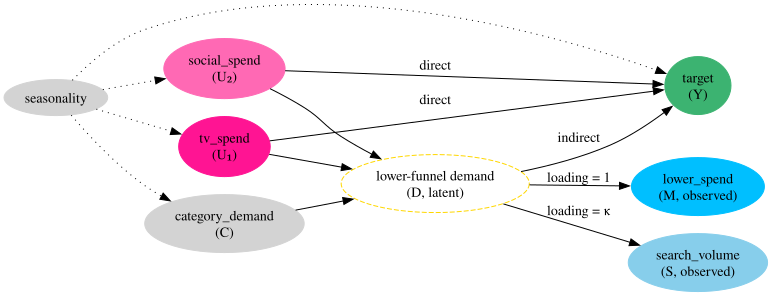

In [1]:
import graphviz as gr

g = gr.Digraph()
g.attr(rankdir="LR")
g.attr("node", shape="ellipse")

g.node("S1", "seasonality", color="lightgray", style="filled")
g.node("U1", "tv_spend\n(U₁)", color="deeppink", style="filled")
g.node("U2", "social_spend\n(U₂)", color="hotpink", style="filled")
g.node("C", "category_demand\n(C)", color="lightgray", style="filled")
g.node("D", "lower-funnel demand\n(D, latent)", color="gold", style="dashed")
g.node("M", "lower_spend\n(M, observed)", color="deepskyblue", style="filled")
g.node("SV", "search_volume\n(S, observed)", color="skyblue", style="filled")
g.node("Y", "target\n(Y)", color="mediumseagreen", style="filled")

g.edge("S1", "U1", style="dotted")
g.edge("S1", "U2", style="dotted")
g.edge("S1", "C", style="dotted")
g.edge("S1", "Y", style="dotted")
g.edge("U1", "Y", label="direct")
g.edge("U2", "Y", label="direct")
g.edge("U1", "D")
g.edge("U2", "D")
g.edge("C", "D")
g.edge("D", "M", label="loading = 1")
g.edge("D", "SV", label="loading = κ")
g.edge("D", "Y", label="indirect")

g

The whole graph is replicated across geos. Which parameters are shared and which
are free per geo is a modeling choice, and with roughly 130 weeks per geo it is a
consequential one:

| Parameter | Dimensions | Why |
|---|---|---|
| `adstock_alpha`, `adstock_uf_alpha`, `saturation_lam`, `sat_uf_lam` | `("channel",)` | Carryover and curvature are properties of the medium, not the region; pooling them buys a lot of precision. |
| `saturation_beta`, `sat_uf_beta` | `("geo", "channel")` | Response *amplitude* genuinely differs by region (market size, competition). |
| `intercept`, `funnel_baseline`, `funnel_gamma`, the noise scales | `("geo",)` | Regional levels and volatility. |
| `funnel_kappa` | scalar | The search index is the same instrument everywhere, so its loading is shared. |

Mixing pooled and unpooled parameters in one expression is where xtensors earn
their keep: `pymc.dims` aligns operands **by dimension name**, so a
`("channel",)` decay multiplies a `("date", "geo", "channel")` media array with no
manual broadcasting.

## Prepare Notebook

In [2]:
import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor.tensor as pt
import seaborn as sns
import xarray as xr
from pydantic import InstanceOf
from pymc import do
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.additive_effect import DataVarMuEffect
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.mmm.mmm import MMM

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [3]:
seed: int = sum(map(ord, "advanced funnel"))
rng: np.random.Generator = np.random.default_rng(seed=seed)


def hdi_bounds(da, prob: float = 0.94):
    """Return (lower, upper) HDI DataArrays for a posterior DataArray."""
    h = az.hdi(da, prob=prob)
    if isinstance(h, xr.Dataset):
        h = h[next(iter(h.data_vars))]
    return h.sel(ci_bound="lower"), h.sel(ci_bound="upper")

## Configuration

In [4]:
n_dates = 130
l_max = 8
geos = ["north", "south", "west"]
channels = ["tv_spend", "social_spend"]

date_range = pd.date_range(start="2021-01-04", freq="W-MON", periods=n_dates)
coords = {"date": date_range, "geo": geos}

## The `FunnelEffect` component

A {class}`~pymc_marketing.mmm.additive_effect.MuEffect` adds an arbitrary term to
the target mean through a three-method protocol: `create_data` registers the data
the effect needs, `create_effect` builds and returns the term, and `set_data`
refreshes the data at prediction time. Because `create_effect` runs *inside* the
model context, it can declare **its own observed likelihoods** -- which is what
turns "add a term to `mu`" into "fit extra structural equations jointly".

{class}`~pymc_marketing.mmm.additive_effect.DataVarMuEffect` removes most of that
boilerplate. It takes a list of `data_vars` naming variables in the training
dataset and implements `create_data` and `set_data` for us, registering each one
with the dimensions it already carries in the dataset. Compared with the
hand-written effect in {ref}`mmm_funnel_mueffect`, this deletes the data-carrying
fields, `create_data`, and `set_data` -- and it fixes a subtle limitation of the
hand-rolled version, whose `set_data` ignored the prediction frame entirely.

The `MediaTransformation` helper does the same for the adstock/saturation pairs:
instead of four loose components, we hold two transformation objects and let each
manage its own ordering and prior dimensions.

What remains in `create_effect` is exactly the part that *is* the funnel:

In [5]:
class FunnelEffect(DataVarMuEffect):
    """Geo-level upper-funnel mediation with two demand-proxy likelihoods.

    Encodes ``upper channels -> latent lower-funnel demand -> target`` as an
    additive effect on the target mean, while jointly fitting two noisy
    measurements of the latent demand.
    """

    upper_transform: InstanceOf[MediaTransformation]
    demand_transform: InstanceOf[MediaTransformation]

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize the effect (transformations delegate to their own dicts)."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "upper_transform": self.upper_transform.to_dict(),
            "demand_transform": self.demand_transform.to_dict(),
        }

    def create_effect(self, mmm):
        """Build the mediator equation, its likelihoods, and the target effect."""
        model = mmm.model

        # ("date", "geo", "channel") -> ("date", "geo"): every upper channel
        # pushes on the same demand pool, so we sum the channel dimension away.
        upper_on_demand = self.upper_transform(mmm.channel_data_scaled, dim="date").sum(
            dim="channel"
        )

        # Structural equation 1: upper spend + category demand -> latent demand.
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0, dims=("geo",))
        gamma = pmd.HalfNormal(f"{self.prefix}_gamma", sigma=1.0, dims=("geo",))
        demand = pmd.Deterministic(
            f"{self.prefix}_demand",
            baseline + gamma * model["category_demand"] + upper_on_demand,
        )

        # Measurement 1: lower-funnel spend, loading fixed at 1 to anchor D's scale.
        pmd.TruncatedNormal(
            f"{self.prefix}_lower_spend_likelihood",
            mu=demand,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma_m", sigma=1.0, dims=("geo",)),
            lower=0.0,
            observed=model["lower_spend"],
        )

        # Measurement 2: branded search volume, with a free (shared) loading.
        kappa = pmd.HalfNormal(f"{self.prefix}_kappa", sigma=1.0)
        pmd.Normal(
            f"{self.prefix}_search_likelihood",
            mu=kappa * demand,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma_s", sigma=1.0, dims=("geo",)),
            observed=model["search_volume"],
        )

        # Structural equation 2: latent demand -> target contribution.
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.demand_transform(demand, dim="date"),
        )

The factory below wires up the two transformations and, crucially, sets the
**dimensions of each prior** according to the pooling table above. `GeometricAdstock`
and `LogisticSaturation` accept a `priors` dictionary, so `alpha` and `lam` get
`dims="channel"` (pooled across geos) while `beta` gets `dims=("geo", "channel")`.
Unique `prefix` values keep these parameters from colliding with the base `MMM`'s
own direct-path transforms.

In [6]:
def make_funnel_effect() -> FunnelEffect:
    """Construct the funnel effect with uniquely-prefixed transformations."""
    return FunnelEffect(
        data_vars=["lower_spend", "search_volume", "category_demand"],
        prefix="funnel",
        upper_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max,
                prefix="adstock_uf",
                priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="channel")},
            ),
            saturation=LogisticSaturation(
                prefix="sat_uf",
                priors={
                    "lam": Prior("Gamma", mu=2.0, sigma=1.0, dims="channel"),
                    "beta": Prior("HalfNormal", sigma=1.0, dims=("geo", "channel")),
                },
            ),
            adstock_first=True,
            dims=("geo", "channel"),
        ),
        demand_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max,
                prefix="adstock_lf",
                priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="geo")},
            ),
            saturation=LogisticSaturation(
                prefix="sat_lf",
                priors={
                    "lam": Prior("Gamma", mu=1.5, sigma=0.5),
                    "beta": Prior("HalfNormal", sigma=1.0, dims="geo"),
                },
            ),
            adstock_first=True,
            dims=("geo",),
        ),
    )

### A note on data plumbing

`DataVarMuEffect` looks its variables up in `mmm.xarray_dataset`, the dataset the
`MMM` stores when the model is built. That has a practical consequence worth
stating plainly, because it is easy to trip over:

> **A `pandas.DataFrame` will silently drop your funnel columns.** When `X` is a
> DataFrame, the conversion keeps only the channel and control columns; anything
> else disappears. To make extra variables visible to the effect, build the model
> from an `xarray.Dataset`, where every data variable survives.

There is a second wrinkle. `MMM.fit` records a `fit_data` group by converting `X`
back to a flat frame, and that bookkeeping step does not currently handle a
`Dataset` whose media variable carries a `channel` dimension. So we **build** with
the `Dataset` (which is what populates the model) and **fit** with the equivalent
long DataFrame (which is only used for bookkeeping, since `fit` does not rebuild
an already-built model). The model itself is entirely determined by the `Dataset`.

## Data generating process

As in {ref}`mmm_data_generator`, we build a model, clamp every parameter to a
known value with the
[`do`](https://www.pymc.io/projects/docs/en/stable/api/model/generated/pymc.model.transform.conditioning.do.html)
operator, and forward-sample. The generative model **is** the funnel MMM, so one
forward pass produces the target and both demand proxies at once.

### Exogenous covariates

The three exogenous drivers -- two media plans and the category demand index --
share a common annual seasonal component, which is precisely the confounding we
want. Each has its own level, trend and seasonal amplitude; correlated noise comes
from an LKJ prior, and a `softplus` keeps everything non-negative. Regions are
then scaled by a size multiplier.

In [7]:
t = np.arange(n_dates) / n_dates
week_of_year = date_range.isocalendar().week.to_numpy() / 52.0
season = np.sin(2 * np.pi * week_of_year)

drivers = ["tv_spend", "social_spend", "category_demand"]
geo_size = np.array([1.0, 0.7, 0.45])

level = np.array([0.10, 0.05, 0.30])
trend = np.array([0.30, 0.25, 0.10])
seasonal_amplitude = np.array([0.80, 0.40, 0.70])

cov_coords = {"date": date_range, "geo": geos, "driver": drivers}
with pm.Model(coords=cov_coords) as covariates_model:
    L, _, _ = pm.LKJCholeskyCov("L", n=3, eta=50, sd_dist=pm.Exponential.dist(lam=4.0))
    mu_cov = (
        level + trend * t[:, None, None] + seasonal_amplitude * season[:, None, None]
    )
    x_raw = pm.MvNormal("x_raw", mu=mu_cov, chol=L, dims=("date", "geo", "driver"))
    x = pm.Deterministic("x", pt.softplus(x_raw), dims=("date", "geo", "driver"))

In [8]:
x_data = pm.draw(covariates_model.x, draws=1, random_seed=rng) * geo_size[None, :, None]

media_raw = x_data[..., :2]
category_demand = x_data[..., 2] / x_data[..., 2].max()

for gi, geo in enumerate(geos):
    print(
        f"{geo:6s} corr(tv, category) = "
        f"{np.corrcoef(media_raw[:, gi, 0], category_demand[:, gi])[0, 1]:+.2f}"
        f" | corr(social, category) = "
        f"{np.corrcoef(media_raw[:, gi, 1], category_demand[:, gi])[0, 1]:+.2f}"
    )

north  corr(tv, category) = +0.33 | corr(social, category) = +0.70
south  corr(tv, category) = +0.56 | corr(social, category) = +0.73
west   corr(tv, category) = +0.41 | corr(social, category) = +0.70


Social spend tracks category demand much more closely than TV does. Keep that in
mind -- it will decide *where* the omitted-mediator bias lands.

### Ground-truth parameters

Every structural parameter gets an explicit true value, with the shape implied by
its dimensions. Rather than trusting our memory of which parameter is pooled, we
build the model first and read the dimensions off it.

In [9]:
true = {
    # target equation: direct paths and seasonality
    "intercept_contribution": np.array([0.35, 0.28, 0.22]),
    "adstock_alpha": np.array([0.55, 0.30]),
    "saturation_lam": np.array([3.0, 4.0]),
    "saturation_beta": np.array([[0.55, 0.35], [0.45, 0.30], [0.35, 0.25]]),
    "gamma_fourier": np.array(
        [
            [0.05, 0.03, 0.02, -0.02],
            [0.04, 0.02, 0.02, -0.01],
            [0.03, 0.02, 0.01, -0.01],
        ]
    ),
    "y_sigma": np.array([0.04, 0.04, 0.04]),
    # mediator equation: upper spend + category demand -> latent demand
    "funnel_baseline": np.array([0.20, 0.16, 0.12]),
    "funnel_gamma": np.array([0.35, 0.30, 0.25]),
    "adstock_uf_alpha": np.array([0.60, 0.35]),
    "sat_uf_lam": np.array([2.5, 3.0]),
    "sat_uf_beta": np.array([[0.85, 0.55], [0.70, 0.45], [0.55, 0.35]]),
    # measurement equations
    "funnel_sigma_m": np.array([0.05, 0.05, 0.05]),
    "funnel_kappa": np.array(0.8),
    "funnel_sigma_s": np.array([0.05, 0.05, 0.05]),
    # lower-funnel path: latent demand -> target
    "adstock_lf_alpha": np.array([0.35, 0.30, 0.25]),
    "sat_lf_lam": np.array(1.5),
    "sat_lf_beta": np.array([0.95, 0.80, 0.65]),
}

### Model configuration

The same priors are used for the generative model and for the models we fit, so we
define them once. Note the `scaling` block: `dims=()` means "take the maximum over
the date dimension only", giving one scale per geo (and per channel), which is the
usual choice for a geo panel where regions differ in size.

In [10]:
SCALING = {
    "channel": {"method": "max", "dims": ()},
    "target": {"method": "max", "dims": ()},
}

MODEL_CONFIG = {
    "intercept": Prior("Normal", mu=0.2, sigma=0.2, dims="geo"),
    "gamma_fourier": Prior("Normal", mu=0, sigma=0.1, dims=("geo", "fourier_mode")),
    "likelihood": Prior(
        "Normal",
        sigma=Prior("HalfNormal", sigma=0.5, dims="geo"),
        dims=("date", "geo"),
    ),
}


def make_mmm(channel_columns: list[str], **kwargs) -> MMM:
    """Build the base MMM shared by the generative and fitted models."""
    return MMM(
        date_column="date",
        target_column="y",
        channel_columns=channel_columns,
        dims=("geo",),
        scaling=SCALING,
        adstock=GeometricAdstock(
            l_max=l_max,
            priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="channel")},
        ),
        saturation=LogisticSaturation(
            priors={
                "lam": Prior("Gamma", mu=3.0, sigma=1.0, dims="channel"),
                "beta": Prior("HalfNormal", sigma=1.0, dims=("geo", "channel")),
            }
        ),
        yearly_seasonality=2,
        model_config=MODEL_CONFIG,
        **kwargs,
    )


def make_dataset(media, lower_spend, search_volume, cat_demand) -> xr.Dataset:
    """Assemble the xarray Dataset the funnel model is built from.

    The media variable must be named ``media`` (not ``channel``, which xarray would
    promote to a coordinate) and carry a ``channel`` dimension.
    """
    return xr.Dataset(
        {
            "media": xr.DataArray(media, dims=("date", "geo", "channel")),
            "lower_spend": xr.DataArray(lower_spend, dims=("date", "geo")),
            "search_volume": xr.DataArray(search_volume, dims=("date", "geo")),
            "category_demand": xr.DataArray(cat_demand, dims=("date", "geo")),
        },
        coords={**coords, "channel": channels},
    )

### Forward simulation

We build the generative model on dummy proxies and a dummy target (both ones, so
the target scale is one and the true parameters are on the natural scale), then
clamp and sample.

In [11]:
ones = np.ones((n_dates, len(geos)))
ds_gen = make_dataset(media_raw, ones, ones, category_demand)
y_gen = xr.DataArray(ones, dims=("date", "geo"), coords=coords)

gen = make_mmm(channels)
gen.add_mu_effect(make_funnel_effect())
gen.build_model(X=ds_gen, y=y_gen)
gen.add_original_scale_contribution_variable(
    var=["channel_contribution", "funnel_effect_contribution", "y"]
)

pd.DataFrame(
    [(v, gen.model.named_vars_to_dims.get(v), true[v].shape) for v in true],
    columns=["parameter", "dims", "true value shape"],
)

,parameter,dims,true value shape
0,intercept_contribution,"(geo,)","(3,)"
1,adstock_alpha,"(channel,)","(2,)"
2,saturation_lam,"(channel,)","(2,)"
3,saturation_beta,"(geo, channel)","(3, 2)"
4,gamma_fourier,"(geo, fourier_mode)","(3, 4)"
5,y_sigma,"(geo,)","(3,)"
6,funnel_baseline,"(geo,)","(3,)"
7,funnel_gamma,"(geo,)","(3,)"
8,adstock_uf_alpha,"(channel,)","(2,)"
9,sat_uf_lam,"(channel,)","(2,)"


Reading the dimensions off the model before writing the intervention is a habit
worth keeping: `do` requires the clamped values to match the model's shapes
exactly, and the pooling choices above mean those shapes are not all obvious.

The model graph makes the **three** likelihoods explicit -- the target and the two
demand proxies are all children of the same set of latent parameters.

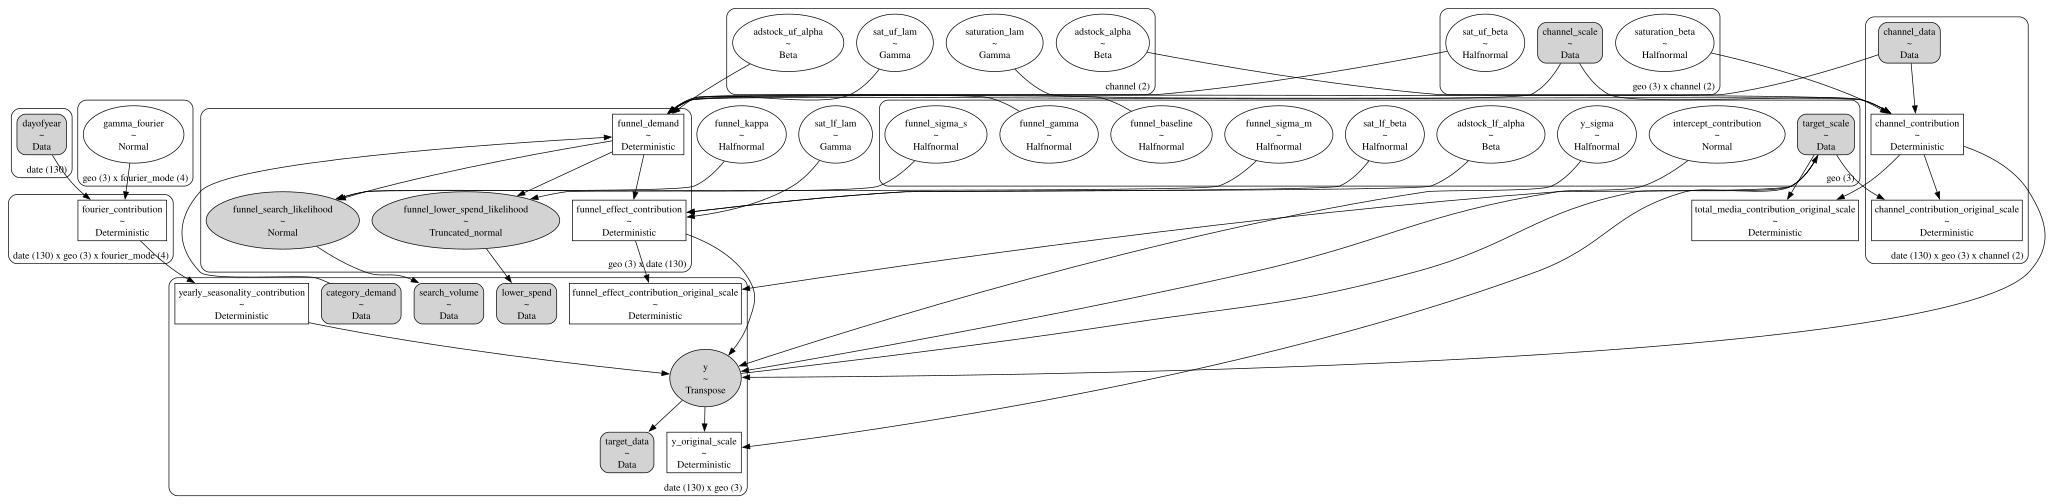

In [12]:
pm.model_to_graphviz(gen.model)

In [13]:
gen.model = do(gen.model, true)

var_names = [
    "y_original_scale",
    "channel_contribution_original_scale",
    "funnel_effect_contribution_original_scale",
    "funnel_demand",
]
pp_names = ["funnel_lower_spend_likelihood", "funnel_search_likelihood"]

with gen.model:
    idata_gen = pm.sample_prior_predictive(
        draws=1, var_names=var_names + pp_names, random_seed=rng
    )

prior = idata_gen["prior"].sel(chain=0, draw=0)
prior_pp = idata_gen["prior_predictive"].sel(chain=0, draw=0)

y_obs = prior["y_original_scale"].transpose("date", "geo").to_numpy()
demand_true = prior["funnel_demand"].transpose("date", "geo").to_numpy()
lower_spend_obs = (
    prior_pp["funnel_lower_spend_likelihood"].transpose("date", "geo").to_numpy()
)
search_obs = prior_pp["funnel_search_likelihood"].transpose("date", "geo").to_numpy()
direct_true = (
    prior["channel_contribution_original_scale"]
    .transpose("date", "geo", "channel")
    .to_numpy()
)
indirect_raw = (
    prior["funnel_effect_contribution_original_scale"]
    .transpose("date", "geo")
    .to_numpy()
)

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_lower_spend_likelihood, funnel_search_likelihood, y]


### The true causal decomposition

The raw `funnel_effect_contribution` includes the demand that comes from the
baseline and the category index, which upper-funnel spend never created. To
isolate each channel's **causal** indirect contribution we re-run the clamped
generative model with that channel's spend set to zero and subtract. Running the
same counterfactual with *both* channels off lets us measure the non-additivity.

In [14]:
def forward_with_zeroed(channel_mask) -> np.ndarray:
    """Mediated contribution when the masked channels are set to zero spend."""
    media_cf = media_raw.copy()
    media_cf[..., channel_mask] = 0.0
    with gen.model:
        pm.set_data({"channel_data": media_cf})
        idata_cf = pm.sample_prior_predictive(
            draws=1,
            var_names=["funnel_effect_contribution_original_scale"],
            random_seed=rng,
        )
    return (
        idata_cf["prior"]
        .sel(chain=0, draw=0)["funnel_effect_contribution_original_scale"]
        .transpose("date", "geo")
        .to_numpy()
    )


indirect_true = np.stack(
    [
        indirect_raw - forward_with_zeroed(np.array([True, False])),
        indirect_raw - forward_with_zeroed(np.array([False, True])),
    ],
    axis=-1,
)
indirect_both = indirect_raw - forward_with_zeroed(np.array([True, True]))

# Restore the generative model's media data.
with gen.model:
    pm.set_data({"channel_data": media_raw})

total_true = direct_true + indirect_true

Sampling: []


Sampling: []


Sampling: []


```{note}
Unlike the single-channel example, we keep the **full** date range rather than
dropping the first `l_max` weeks. The generative model and the fitted models apply
the same zero-padded adstock, so the early weeks are not an artifact. Dropping them
would actually *introduce* one: the fitted model would be asked to explain weeks
whose carryover history had been deleted.
```

In [15]:
data = xr.Dataset(
    {
        "tv_spend": (("date", "geo"), media_raw[..., 0]),
        "social_spend": (("date", "geo"), media_raw[..., 1]),
        "category_demand": (("date", "geo"), category_demand),
        "lower_spend": (("date", "geo"), lower_spend_obs),
        "search_volume": (("date", "geo"), search_obs),
        "y": (("date", "geo"), y_obs),
        "demand_true": (("date", "geo"), demand_true),
        "direct_true": (("date", "geo", "channel"), direct_true),
        "indirect_true": (("date", "geo", "channel"), indirect_true),
        "total_true": (("date", "geo", "channel"), total_true),
    },
    coords={**coords, "channel": channels},
)

shares = (
    data["indirect_true"].mean("date") / data["total_true"].mean("date")
).to_dataframe(name="indirect share")
shares["indirect share"] = shares["indirect share"].map("{:.1%}".format)
shares

indirect share
geo   channel                    
north tv_spend              35.9%
      social_spend          37.8%
south tv_spend              36.8%
      social_spend          36.8%
west  tv_spend              35.5%
      social_spend          33.3%

Between a third and two fifths of every upper-funnel channel's effect travels
through the mediator. Now the non-additivity:

In [16]:
sum_of_singles = float(data["indirect_true"].sum("channel").mean())
joint = float(indirect_both.mean())
print(f"Sum of single-channel indirect effects: {sum_of_singles:.3f}")
print(f"Indirect effect of switching both off:  {joint:.3f}")
print(f"Shortfall from treating paths as additive: {1 - sum_of_singles / joint:.1%}")

Sum of single-channel indirect effects: 0.237
Indirect effect of switching both off:  0.262
Shortfall from treating paths as additive: 9.6%


Because the two channels share one saturating demand pool, per-channel indirect
effects computed one at a time **understate** their joint effect by around 10%.
This is not a bug: with a concave response there is no unique way to split a joint
effect into per-channel pieces, and leave-one-out attribution is one convention
among several. It is worth stating explicitly whenever these numbers inform a
budget conversation.

### Exploratory visualization

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_77251/1021257997.py:24: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


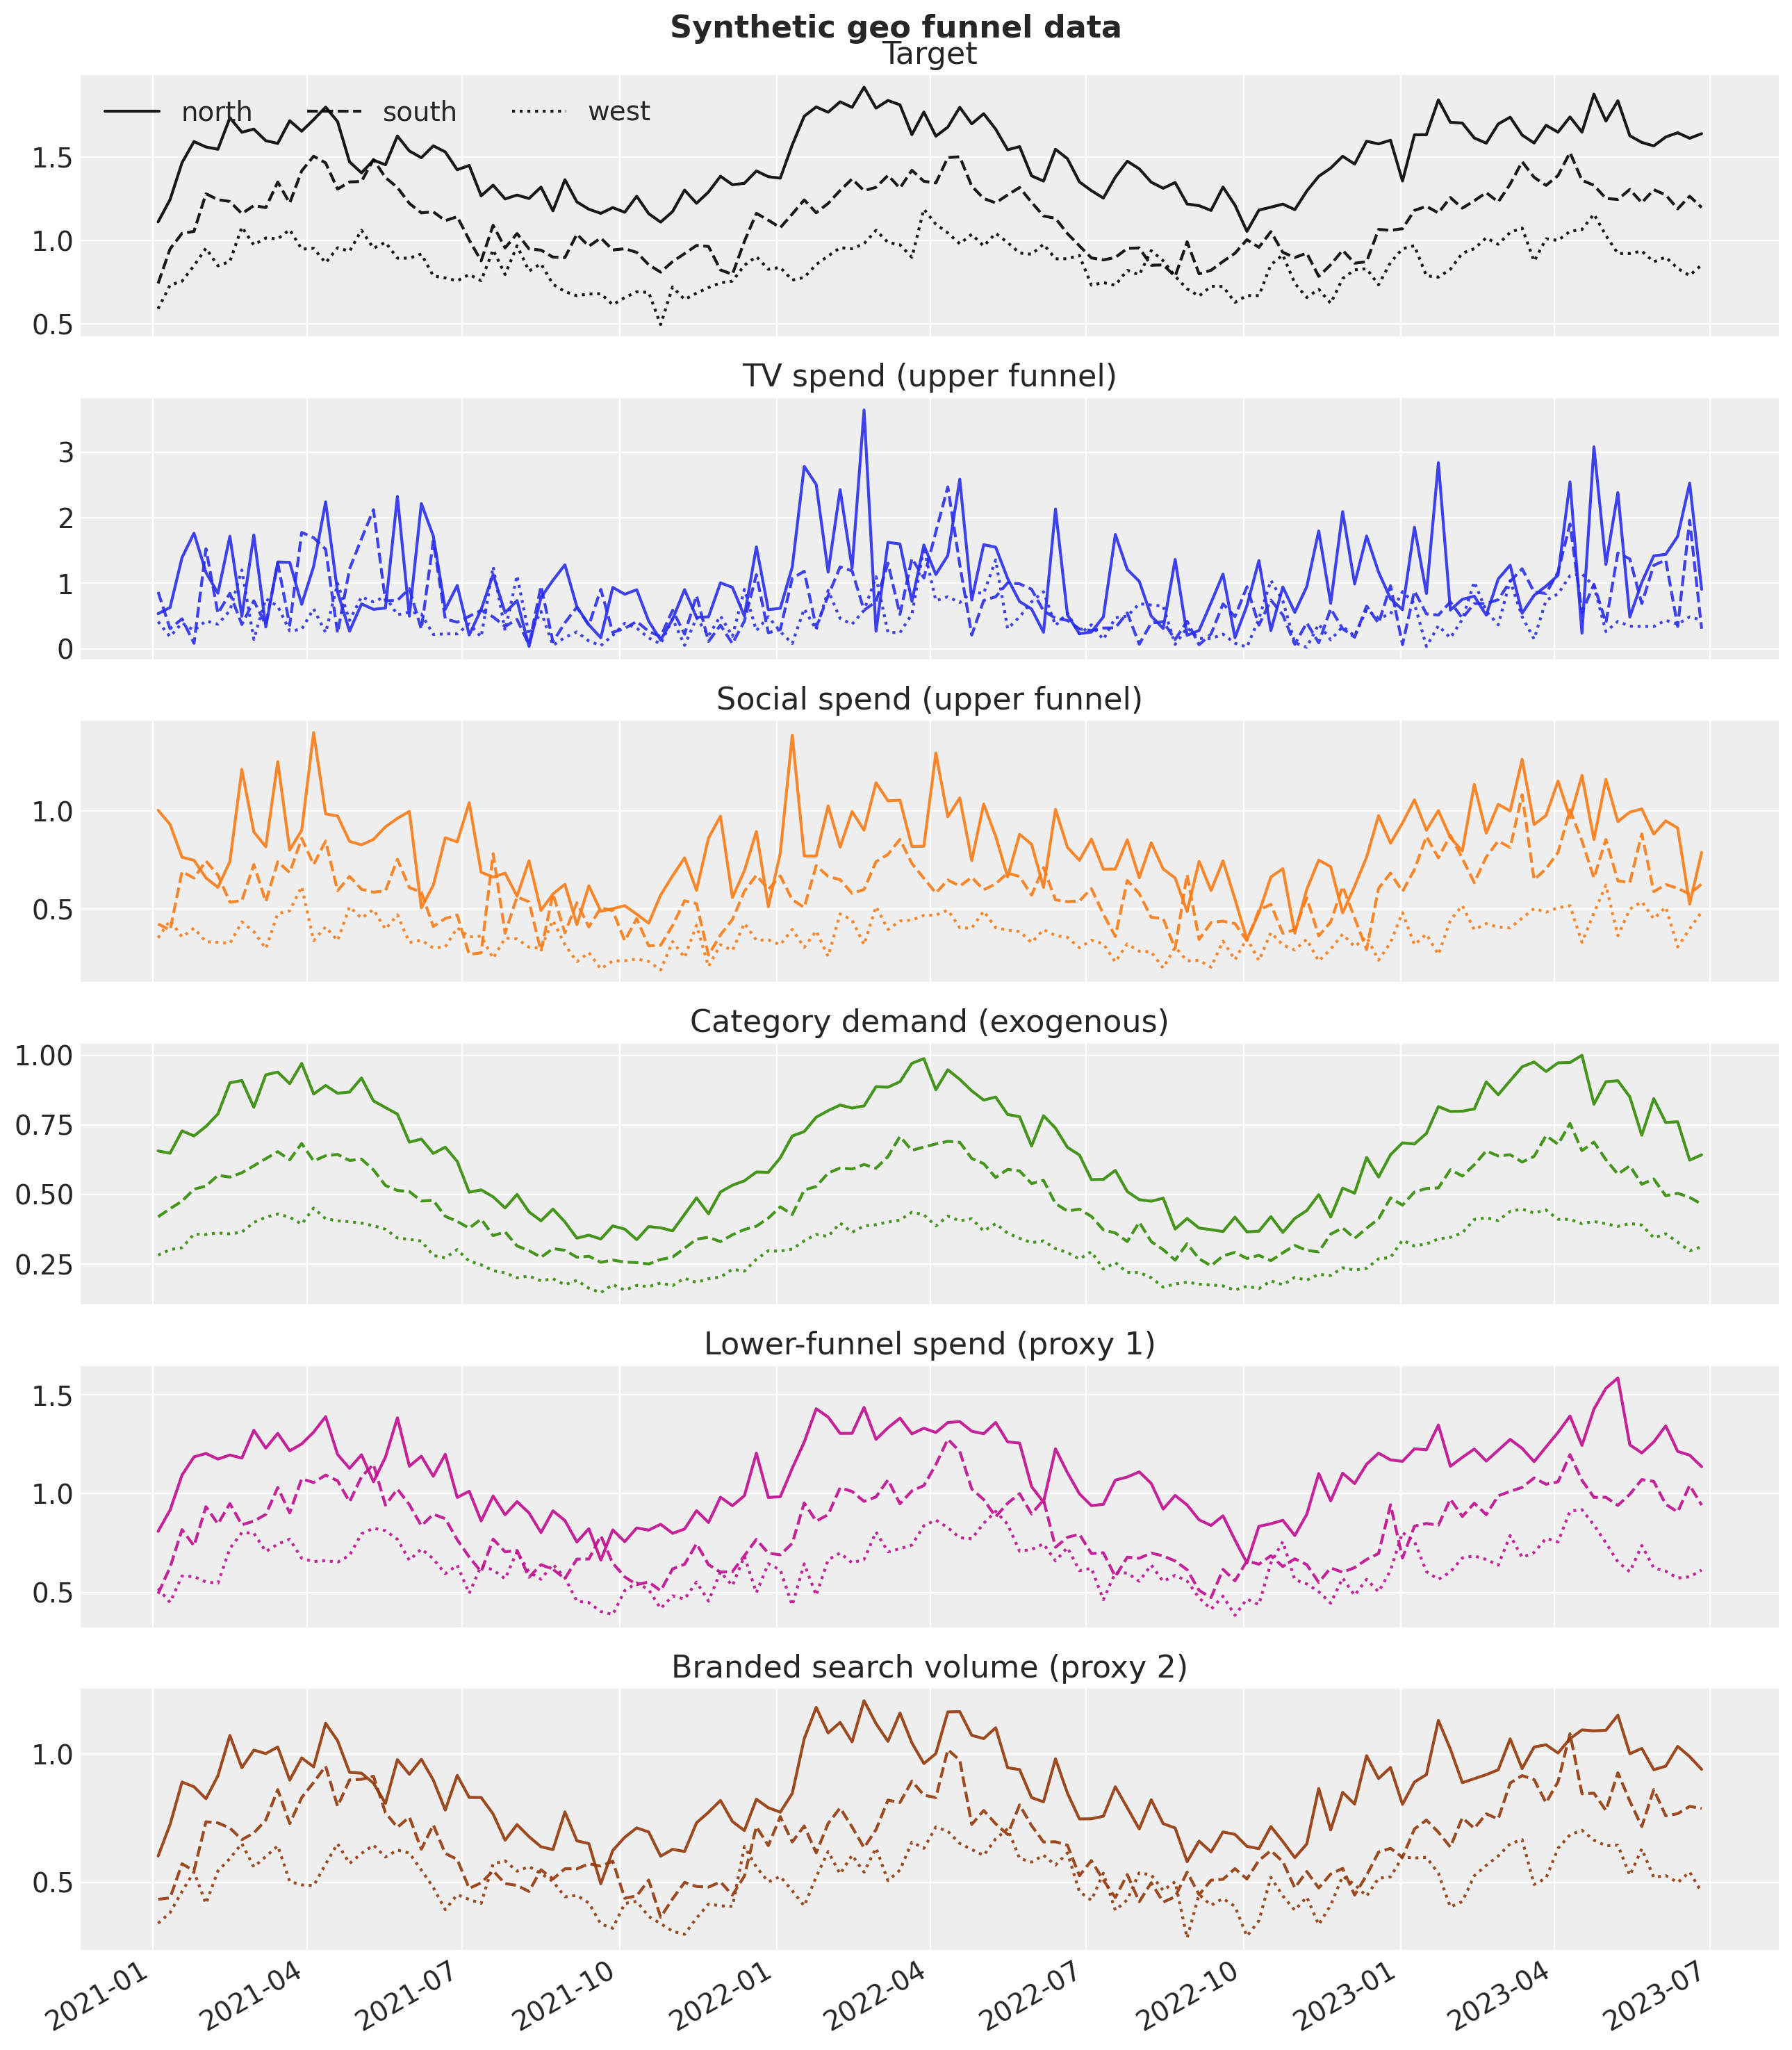

In [17]:
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(13, 15), sharex=True)
series = [
    ("y", "Target", "black"),
    ("tv_spend", "TV spend (upper funnel)", "C0"),
    ("social_spend", "Social spend (upper funnel)", "C1"),
    ("category_demand", "Category demand (exogenous)", "C2"),
    ("lower_spend", "Lower-funnel spend (proxy 1)", "C3"),
    ("search_volume", "Branded search volume (proxy 2)", "C4"),
]
for ax, (name, title, color) in zip(axes, series, strict=True):
    for geo, style in zip(geos, ["-", "--", ":"], strict=True):
        ax.plot(
            date_range,
            data[name].sel(geo=geo),
            linestyle=style,
            color=color,
            label=geo,
            alpha=0.9,
        )
    ax.set(title=title, ylabel="")
axes[0].legend(loc="upper left", ncols=3)
fig.suptitle("Synthetic geo funnel data", fontsize=16, fontweight="bold")
fig.autofmt_xdate()
fig.tight_layout()

The two proxies track the latent demand closely, which is the point: neither is
demand itself, but together they pin it down.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_77251/51616492.py:30: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


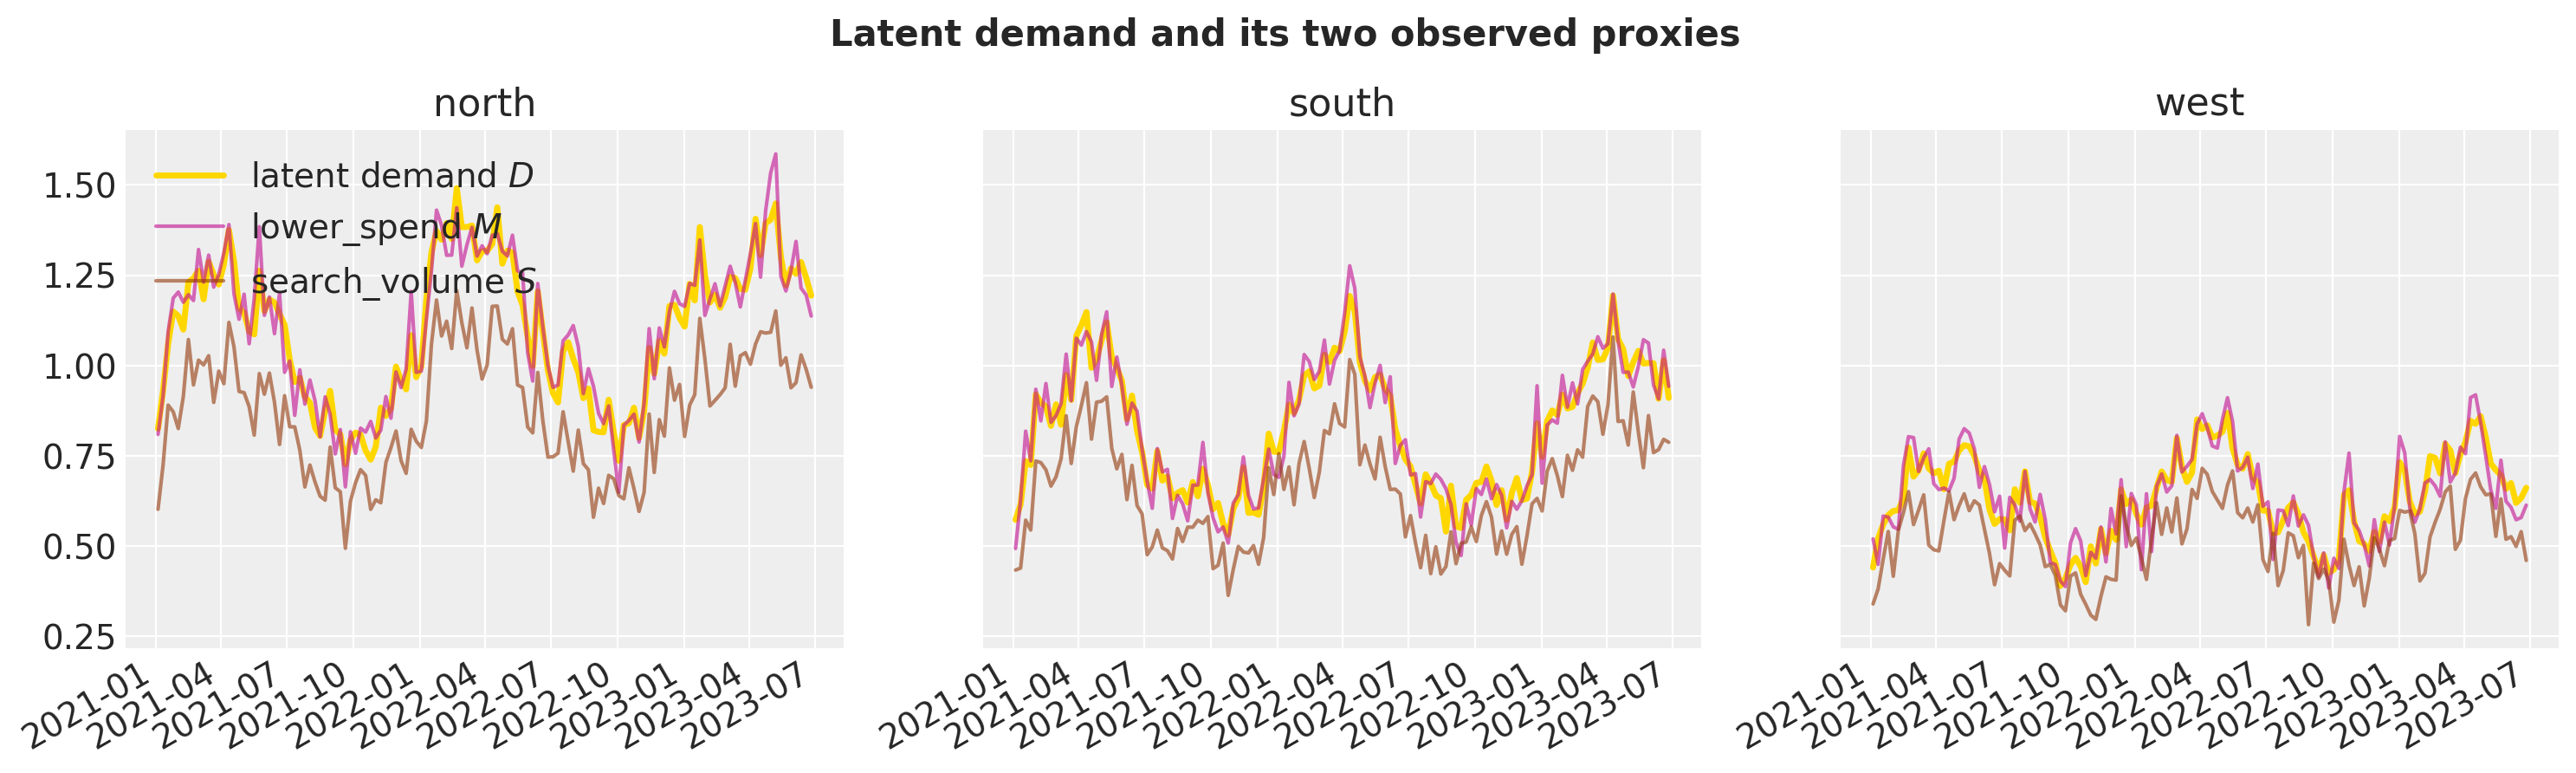

In [18]:
fig, axes = plt.subplots(ncols=len(geos), figsize=(15, 4.5), sharey=True)
for ax, geo in zip(axes, geos, strict=True):
    ax.plot(
        date_range,
        data["demand_true"].sel(geo=geo),
        color="gold",
        lw=2.5,
        label="latent demand $D$",
    )
    ax.plot(
        date_range,
        data["lower_spend"].sel(geo=geo),
        color="C3",
        alpha=0.6,
        label="lower_spend $M$",
    )
    ax.plot(
        date_range,
        data["search_volume"].sel(geo=geo),
        color="C4",
        alpha=0.6,
        label="search_volume $S$",
    )
    ax.set(title=geo)
axes[0].legend(loc="upper left")
fig.suptitle(
    "Latent demand and its two observed proxies", fontsize=15, fontweight="bold"
)
fig.autofmt_xdate()
fig.tight_layout()

## Fitting the models

We fit three models on the synthetic data:

- **Naive A** -- a standard geo MMM with the mediator thrown in as an **ordinary
  channel** alongside the two upper-funnel channels.
- **Naive B** -- a standard geo MMM with the mediator **omitted**.
- **Funnel** -- the joint model with the `FunnelEffect`.

All three share adstock/saturation families, priors, scaling and sampler settings,
so any difference in their conclusions comes from the structure alone.

In [19]:
frame = (
    data[["tv_spend", "social_spend", "lower_spend", "y"]].to_dataframe().reset_index()
)

X_upper = frame[["date", "geo", *channels]]
X_with_mediator = frame[["date", "geo", *channels, "lower_spend"]]
y = frame["y"]

sample_kwargs = dict(
    chains=4, tune=1_000, draws=1_000, target_accept=0.95, random_seed=rng
)
sampler_config = {"nuts_sampler": "nutpie"}

### Naive A: mediator as an ordinary channel

This is what most production MMMs do when they have upper- and lower-funnel spend
in the same table: list them side by side. Conditioning on the mediator **blocks
the indirect path**, so the upper channels are credited with at most their direct
effect and the lower-funnel channel absorbs demand they created.

In [20]:
naive_a = make_mmm([*channels, "lower_spend"], sampler_config=sampler_config)
naive_a.build_model(X_with_mediator, y)
naive_a.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_a.fit(X_with_mediator, y, **sample_kwargs)
naive_a.sample_posterior_predictive(X_with_mediator, random_seed=rng);

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### Naive B: mediator omitted

Here the two upper channels are the only media. Each response curve has to absorb
both the direct effect and the demand created downstream -- and, because there is
no mediator, the seasonal category demand that moves the target has nowhere to go
either. Whichever channel co-moves most with category demand will collect it.

In [21]:
naive_b = make_mmm(channels, sampler_config=sampler_config)
naive_b.build_model(X_upper, y)
naive_b.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_b.fit(X_upper, y, **sample_kwargs)
naive_b.sample_posterior_predictive(X_upper, random_seed=rng);

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### The funnel model

The funnel model has the two upper channels (their direct effects) plus the
`FunnelEffect`, which reads the mediator data from the `Dataset` and fits the
target and both proxies jointly. Note the plumbing discussed earlier: we build
from the `Dataset` and fit with the long frame.

In [22]:
ds_fit = make_dataset(media_raw, lower_spend_obs, search_obs, category_demand)
y_fit = xr.DataArray(y_obs, dims=("date", "geo"), coords=coords)

funnel = make_mmm(channels, sampler_config=sampler_config)
funnel.add_mu_effect(make_funnel_effect())
funnel.build_model(X=ds_fit, y=y_fit)
funnel.add_original_scale_contribution_variable(
    var=["channel_contribution", "funnel_effect_contribution", "y"]
)
funnel.fit(X=X_upper, y=y, **sample_kwargs)
funnel.sample_posterior_predictive(X_upper, random_seed=rng);

NUTS[nutpie]: [y_sigma, adstock_lf_alpha, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_gamma, funnel_baseline, sat_lf_lam, sat_lf_beta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_sigma_s, funnel_kappa, funnel_sigma_m]


Output()

Output()

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_lower_spend_likelihood, funnel_search_likelihood, y]


Output()

### Diagnostics

In [23]:
models = {"Naive A": naive_a, "Naive B": naive_b, "Funnel": funnel}
for label, model in models.items():
    divergences = int(model.idata["sample_stats"]["diverging"].sum())
    max_rhat = float(az.summary(model.idata)["r_hat"].max())
    print(f"{label:8s} | divergences: {divergences:3d} | max r-hat: {max_rhat:.3f}")

Naive A  | divergences:   0 | max r-hat: 1.010


Naive B  | divergences:   0 | max r-hat: 1.010


Funnel   | divergences:   0 | max r-hat: 1.010


### Posterior predictive checks

The funnel model has **three** observed quantities. All of them should be well
recovered.

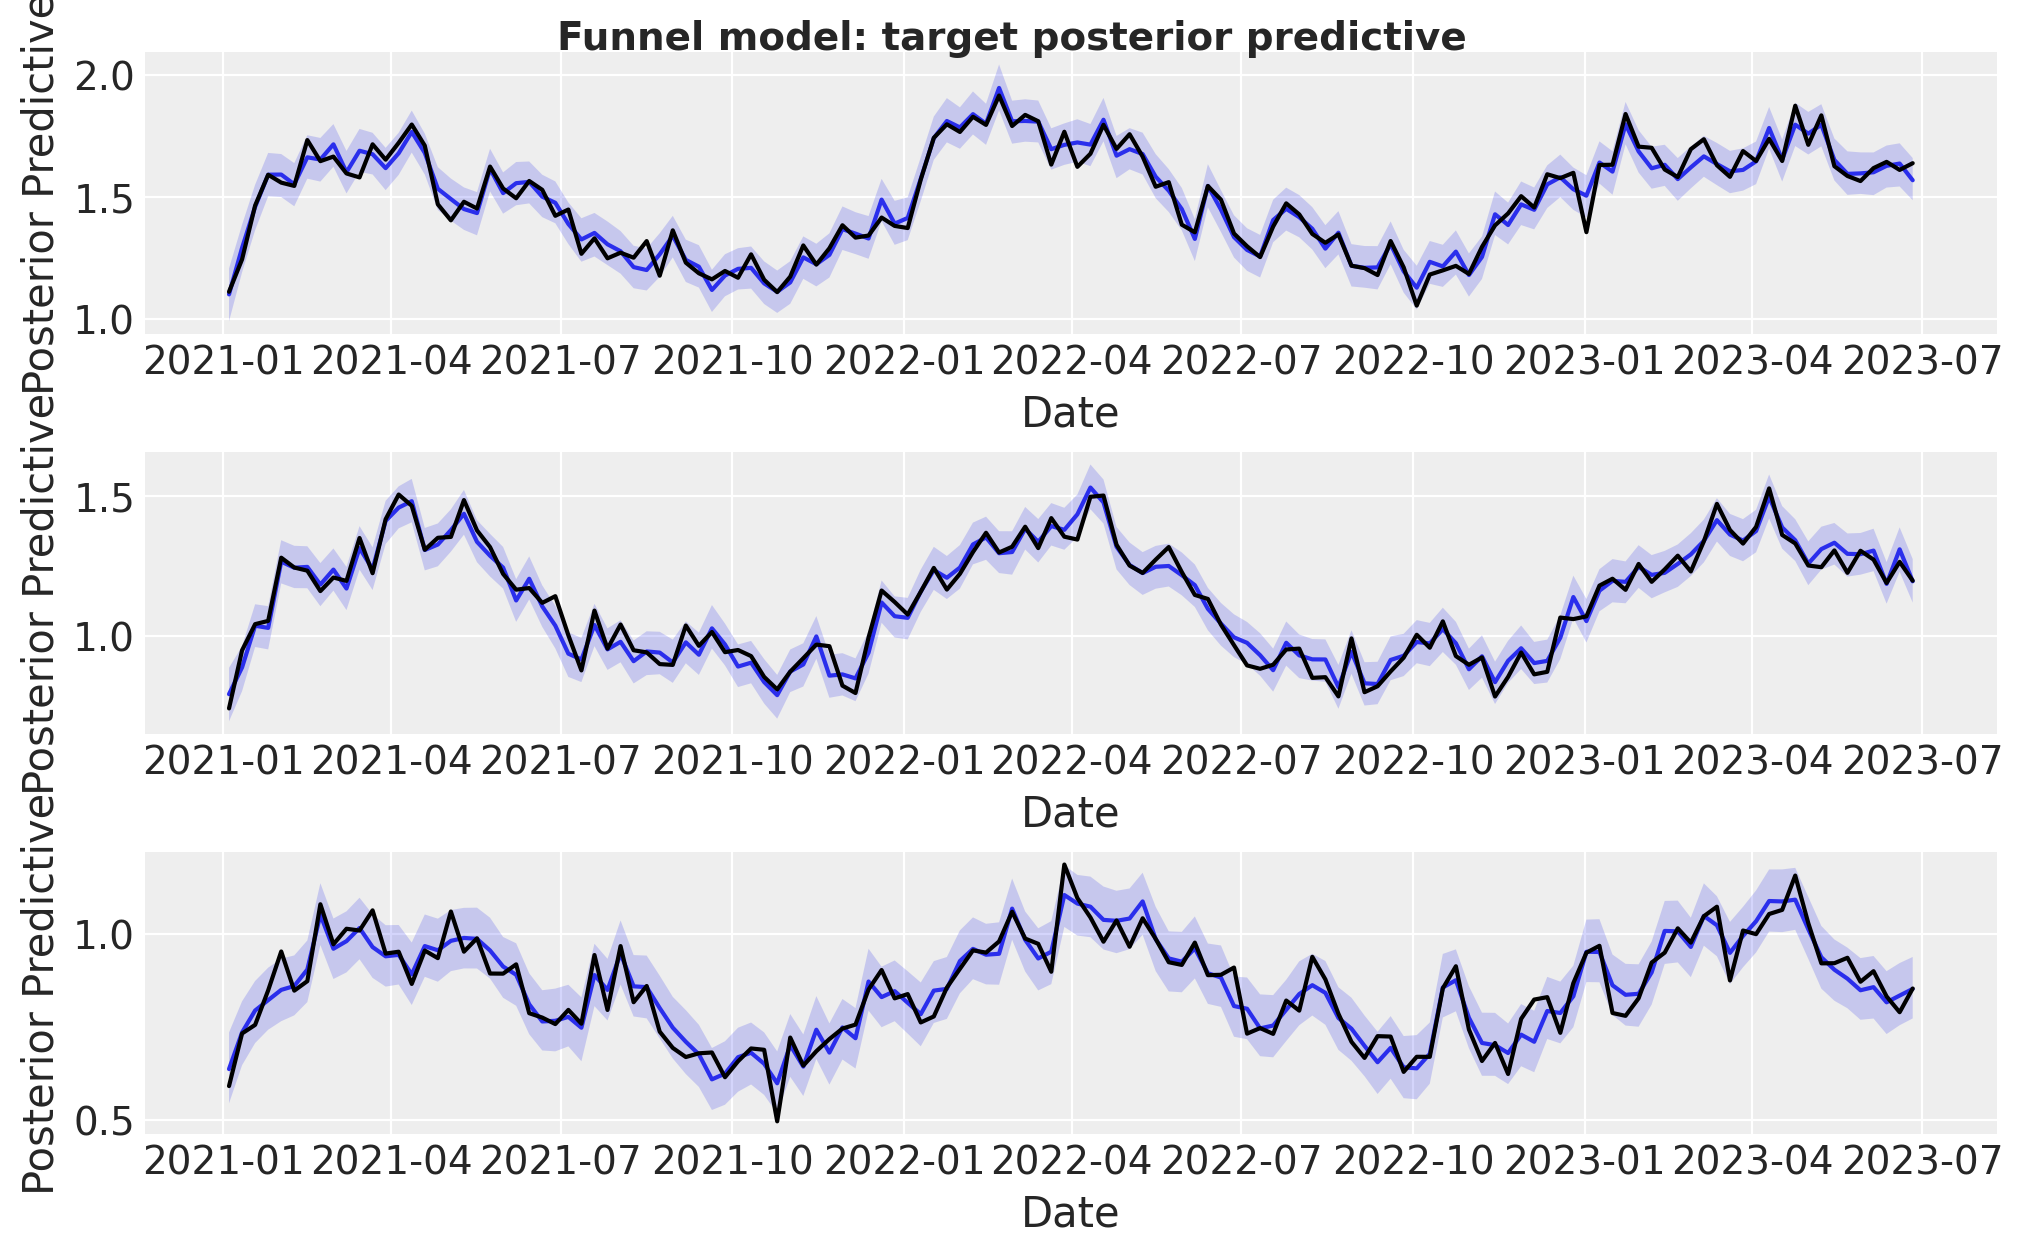

In [24]:
funnel.plot_suite = "new"
fig, axes = funnel.plot.diagnostics.posterior_predictive(hdi_prob=0.94)
fig.suptitle(
    "Funnel model: target posterior predictive", fontsize=14, fontweight="bold", y=1.02
);

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_77251/4010075878.py:34: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


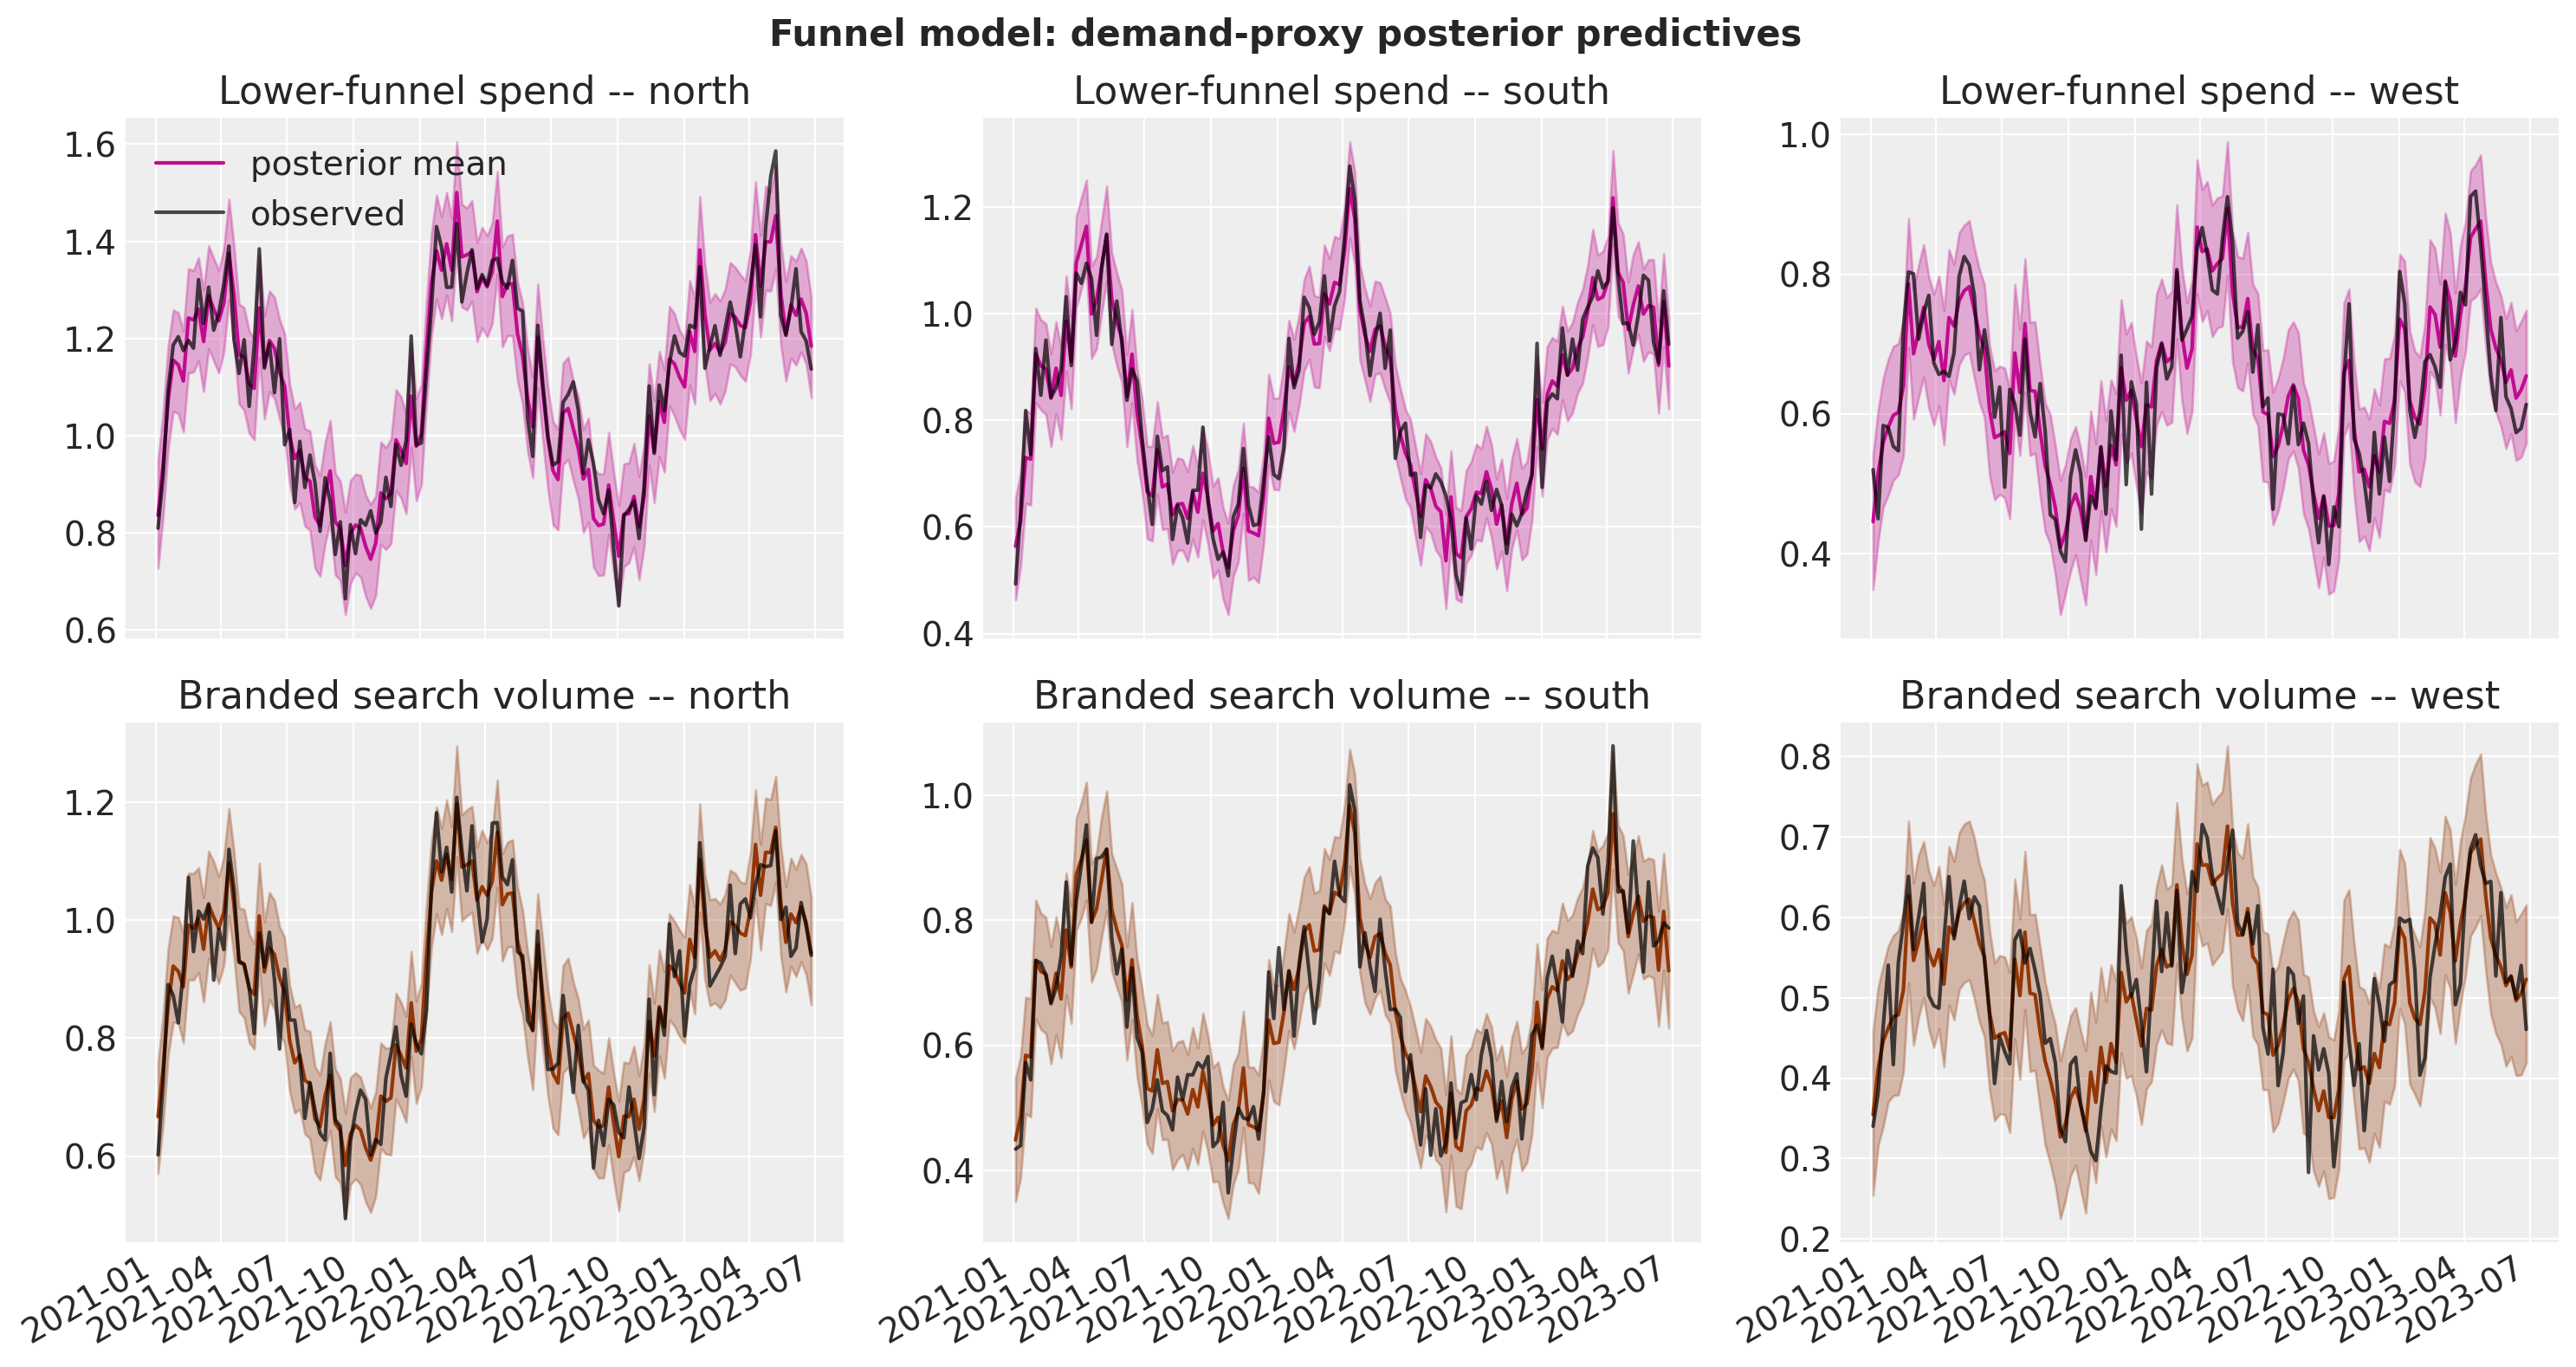

In [25]:
proxies = [
    ("funnel_lower_spend_likelihood", "lower_spend", "Lower-funnel spend", "C3"),
    ("funnel_search_likelihood", "search_volume", "Branded search volume", "C4"),
]

fig, axes = plt.subplots(
    nrows=len(proxies), ncols=len(geos), figsize=(15, 8), sharex=True
)
for row, (var, observed, title, color) in enumerate(proxies):
    pp = funnel.idata.posterior_predictive[var]
    lo, hi = hdi_bounds(pp)
    mean = pp.mean(dim=["chain", "draw"])
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        ax.fill_between(
            date_range, lo.sel(geo=geo), hi.sel(geo=geo), alpha=0.3, color=color
        )
        ax.plot(date_range, mean.sel(geo=geo), color=color, label="posterior mean")
        ax.plot(
            date_range,
            data[observed].sel(geo=geo),
            color="black",
            alpha=0.7,
            label="observed",
        )
        ax.set(title=f"{title} -- {geo}")
axes[0, 0].legend(loc="upper left")
fig.suptitle(
    "Funnel model: demand-proxy posterior predictives",
    fontsize=15,
    fontweight="bold",
)
fig.autofmt_xdate()
fig.tight_layout()

## Parameter recovery

Because we generated the data we can check the funnel model against the truth.
One subtlety carries over from the basic notebook and gets slightly more involved
here: the `MMM` fits on an internally scaled target, so every parameter that acts
on the **scale of the target mean** -- the intercept, the two saturation
amplitudes and the Fourier coefficients -- must be multiplied by `target_scale`
before comparing with the ground truth. With `dims=()` scaling that factor is
**per geo**, and `xarray` applies it by label for us. Parameters acting on the
*inputs* (adstock decays, saturation curvatures) or on the *mediator* scale
(everything in the demand equation) are scale-free and compare directly.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_77251/1647598816.py:59: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


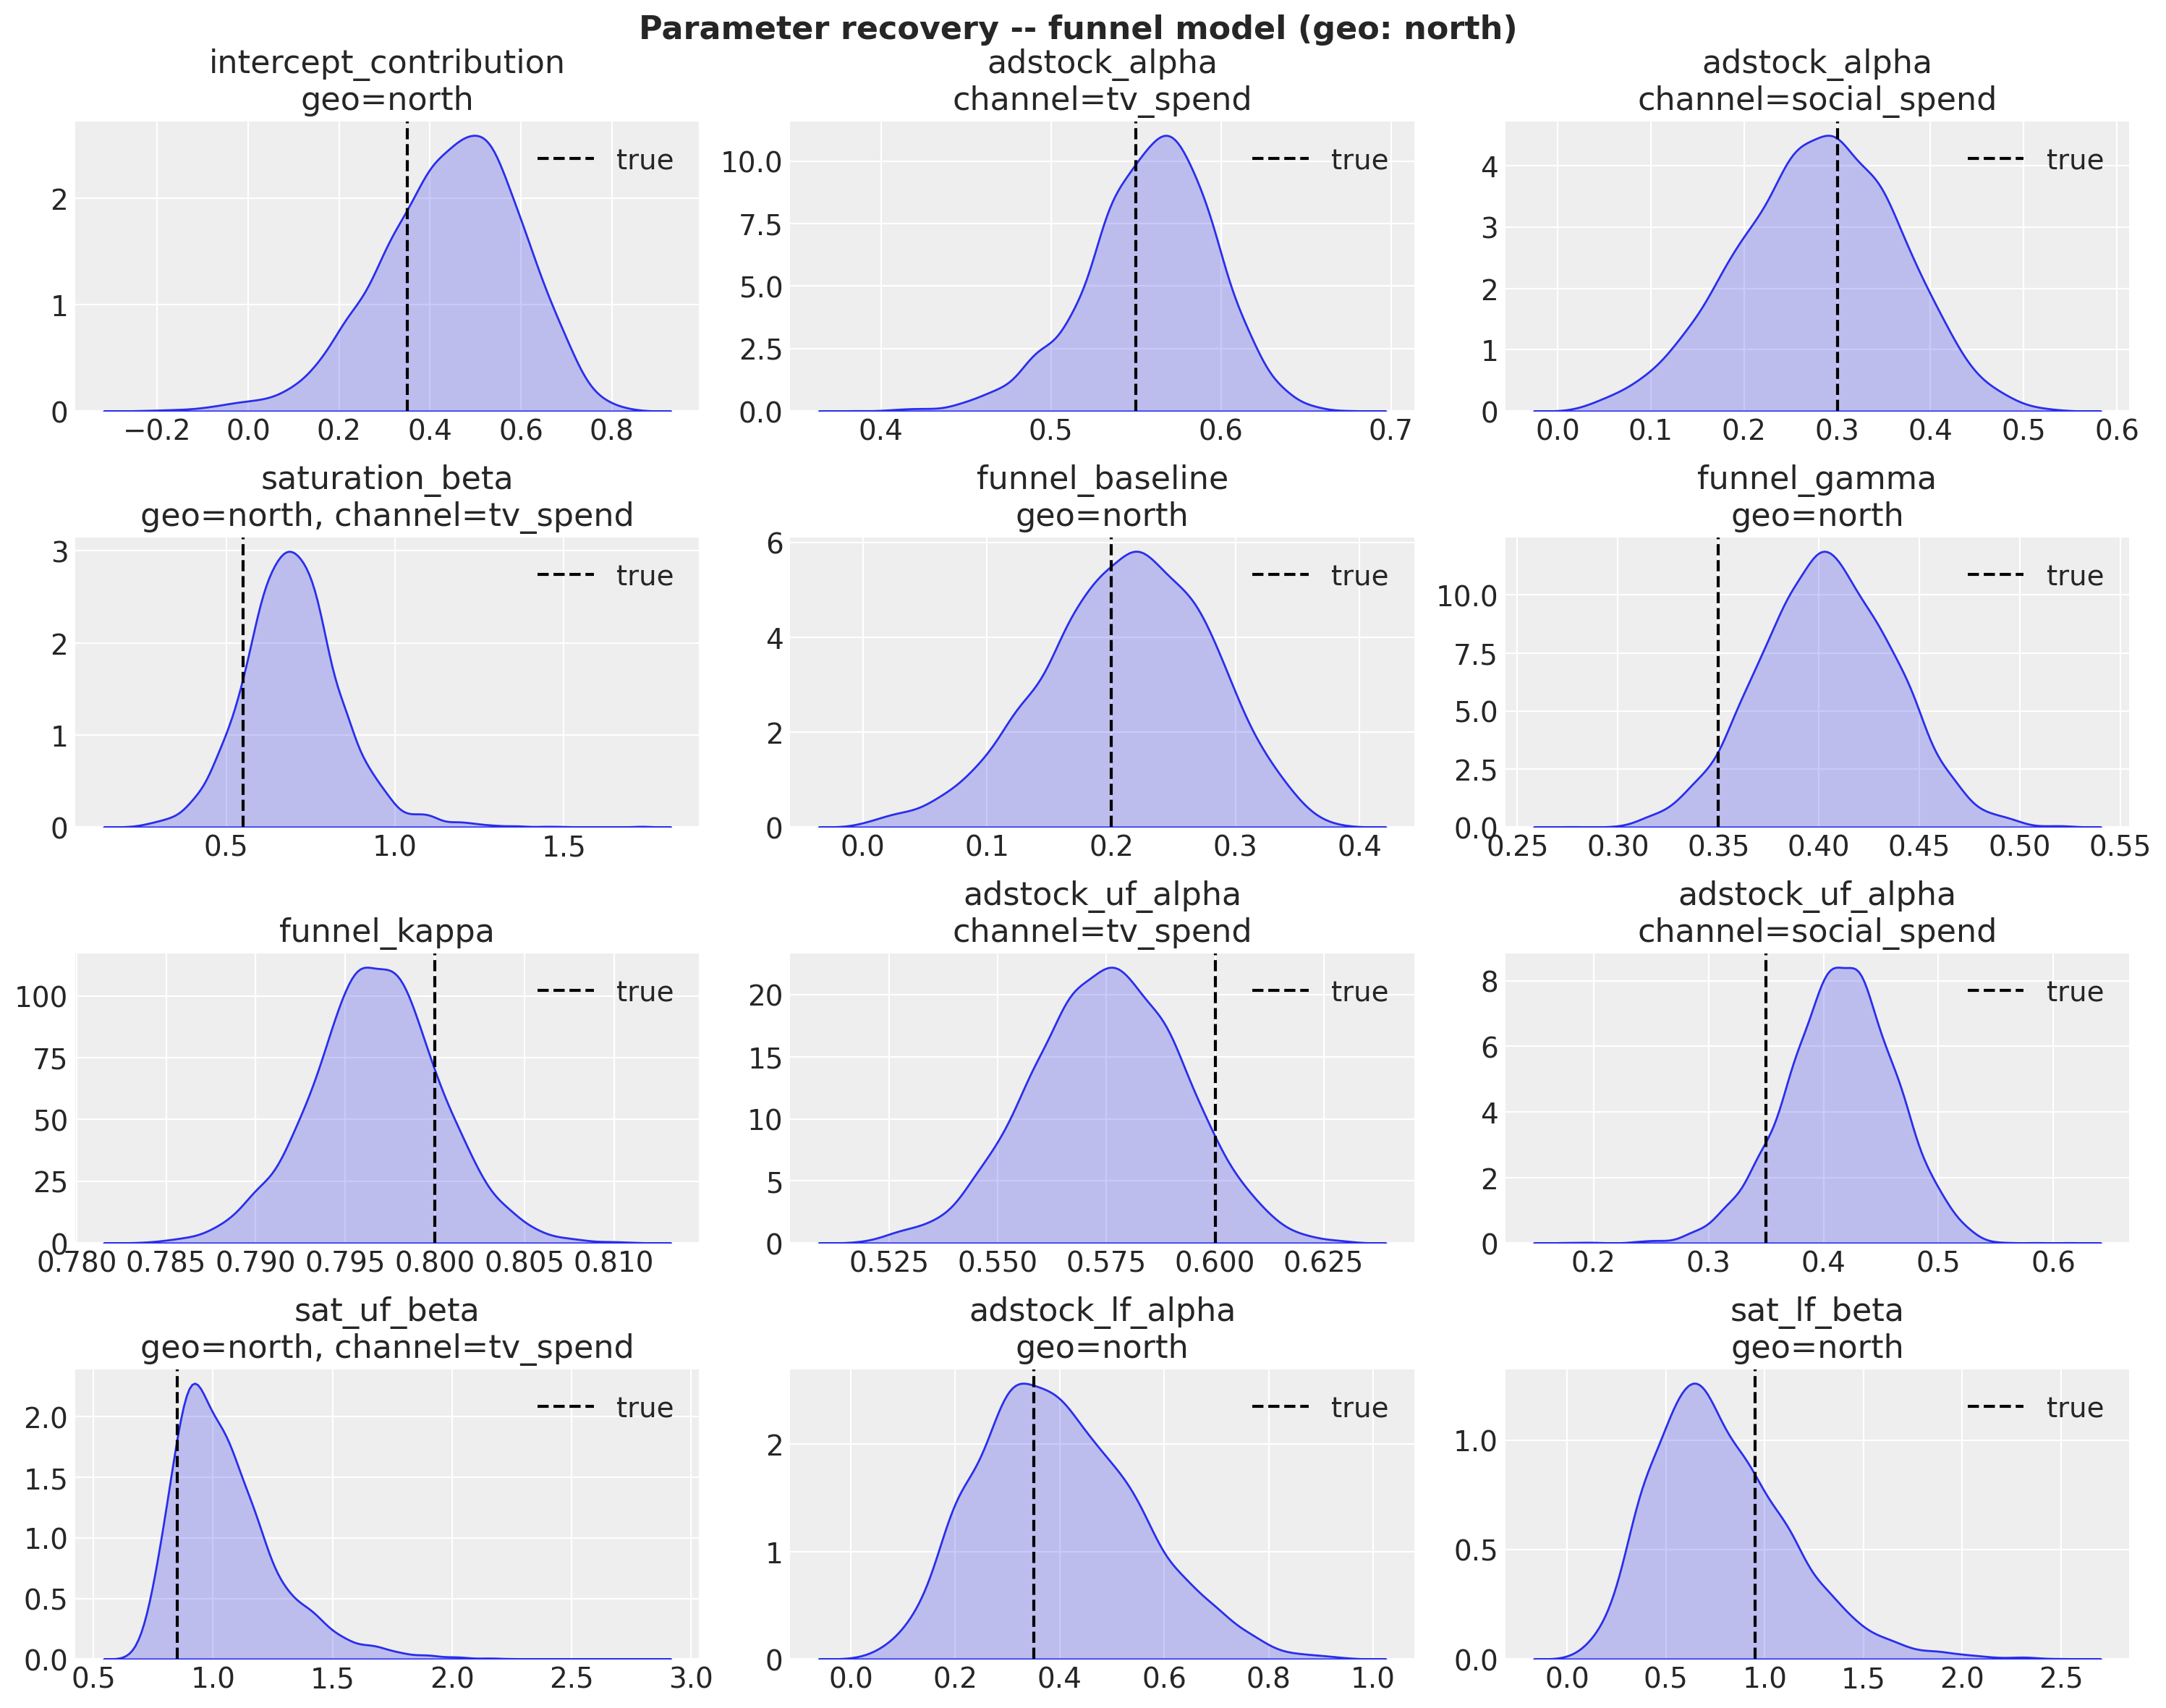

In [26]:
target_scale = funnel.idata.constant_data["target_scale"]
mu_scale_vars = {
    "intercept_contribution",
    "saturation_beta",
    "sat_lf_beta",
    "gamma_fourier",
}


def posterior_on_true_scale(var: str) -> xr.DataArray:
    """Posterior draws for ``var``, rescaled to the ground-truth scale."""
    draws = funnel.idata.posterior[var]
    return draws * target_scale if var in mu_scale_vars else draws


recovery = [
    ("intercept_contribution", {}),
    ("adstock_alpha", {"channel": "tv_spend"}),
    ("adstock_alpha", {"channel": "social_spend"}),
    ("saturation_beta", {"geo": "north", "channel": "tv_spend"}),
    ("funnel_baseline", {"geo": "north"}),
    ("funnel_gamma", {"geo": "north"}),
    ("funnel_kappa", {}),
    ("adstock_uf_alpha", {"channel": "tv_spend"}),
    ("adstock_uf_alpha", {"channel": "social_spend"}),
    ("sat_uf_beta", {"geo": "north", "channel": "tv_spend"}),
    ("adstock_lf_alpha", {"geo": "north"}),
    ("sat_lf_beta", {"geo": "north"}),
]


def true_value(var: str, sel: dict) -> float:
    """Ground-truth scalar for ``var`` at the given selection."""
    dims = funnel.model.named_vars_to_dims.get(var) or ()
    da = xr.DataArray(
        true[var],
        dims=dims,
        coords={d: {"geo": geos, "channel": channels}[d] for d in dims if d != "date"},
    )
    return float(da.sel(sel) if sel else da)


fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
for ax, (var, sel) in zip(axes.flatten(), recovery, strict=True):
    draws = posterior_on_true_scale(var)
    if sel:
        draws = draws.sel(sel)
    if "geo" in draws.dims:
        draws = draws.sel(geo="north")
        sel = {**sel, "geo": "north"}
    sns.kdeplot(draws.to_numpy().ravel(), ax=ax, color="C0", fill=True)
    ax.axvline(true_value(var, sel), color="black", linestyle="--", label="true")
    label = ", ".join(f"{k}={v}" for k, v in sel.items())
    ax.set(title=f"{var}\n{label}" if label else var, ylabel="")
    ax.legend()
fig.suptitle(
    "Parameter recovery -- funnel model (geo: north)", fontsize=16, fontweight="bold"
)
fig.tight_layout()

The pooled carryover parameters land close to the truth, and `funnel_kappa` is
pinned down very tightly -- unsurprisingly, since two likelihoods speak directly
to the demand equation.

Two groups of parameters are looser, for reasons worth naming.

The **saturation amplitudes** (`saturation_beta`, `sat_lf_beta`) are wide because
the direct and indirect paths both originate at upper-funnel spend: how much of
the response belongs to each is only weakly identified individually. And
`funnel_gamma` sits a little above its true value while `adstock_uf_alpha` sits a
little below -- the flip side of the confounding we built in, since a seasonal
category index and seasonally-planned media are partly interchangeable
explanations for seasonal demand.

As in the basic notebook, what matters for a decision is the **total** effect, and
that survives these trade-offs intact, as we see next.

## Direct, indirect, and total effect per channel

We now reconstruct each channel's estimated decomposition. The direct path is the
base channel contribution. The indirect path is the mediated contribution
**minus** what it would be with that channel's spend set to zero -- the same
counterfactual we ran on the generative model, now on the posterior.

In [27]:
def counterfactual_indirect(channel: str) -> xr.DataArray:
    """Posterior mediated contribution attributable to ``channel``."""
    X_zero = X_upper.copy()
    X_zero[channel] = 0.0
    cf = funnel.sample_posterior_predictive(
        X_zero,
        extend_idata=False,
        combined=False,
        var_names=["funnel_effect_contribution_original_scale"],
        random_seed=rng,
    )
    return (
        funnel.idata.posterior["funnel_effect_contribution_original_scale"]
        - cf["funnel_effect_contribution_original_scale"]
    )


direct_post = funnel.idata.posterior["channel_contribution_original_scale"]
indirect_post = xr.concat(
    [counterfactual_indirect(channel) for channel in channels],
    dim=pd.Index(channels, name="channel"),
)
total_post = direct_post + indirect_post

Sampling: []


Output()

Sampling: []


Output()

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_77251/4212185766.py:33: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


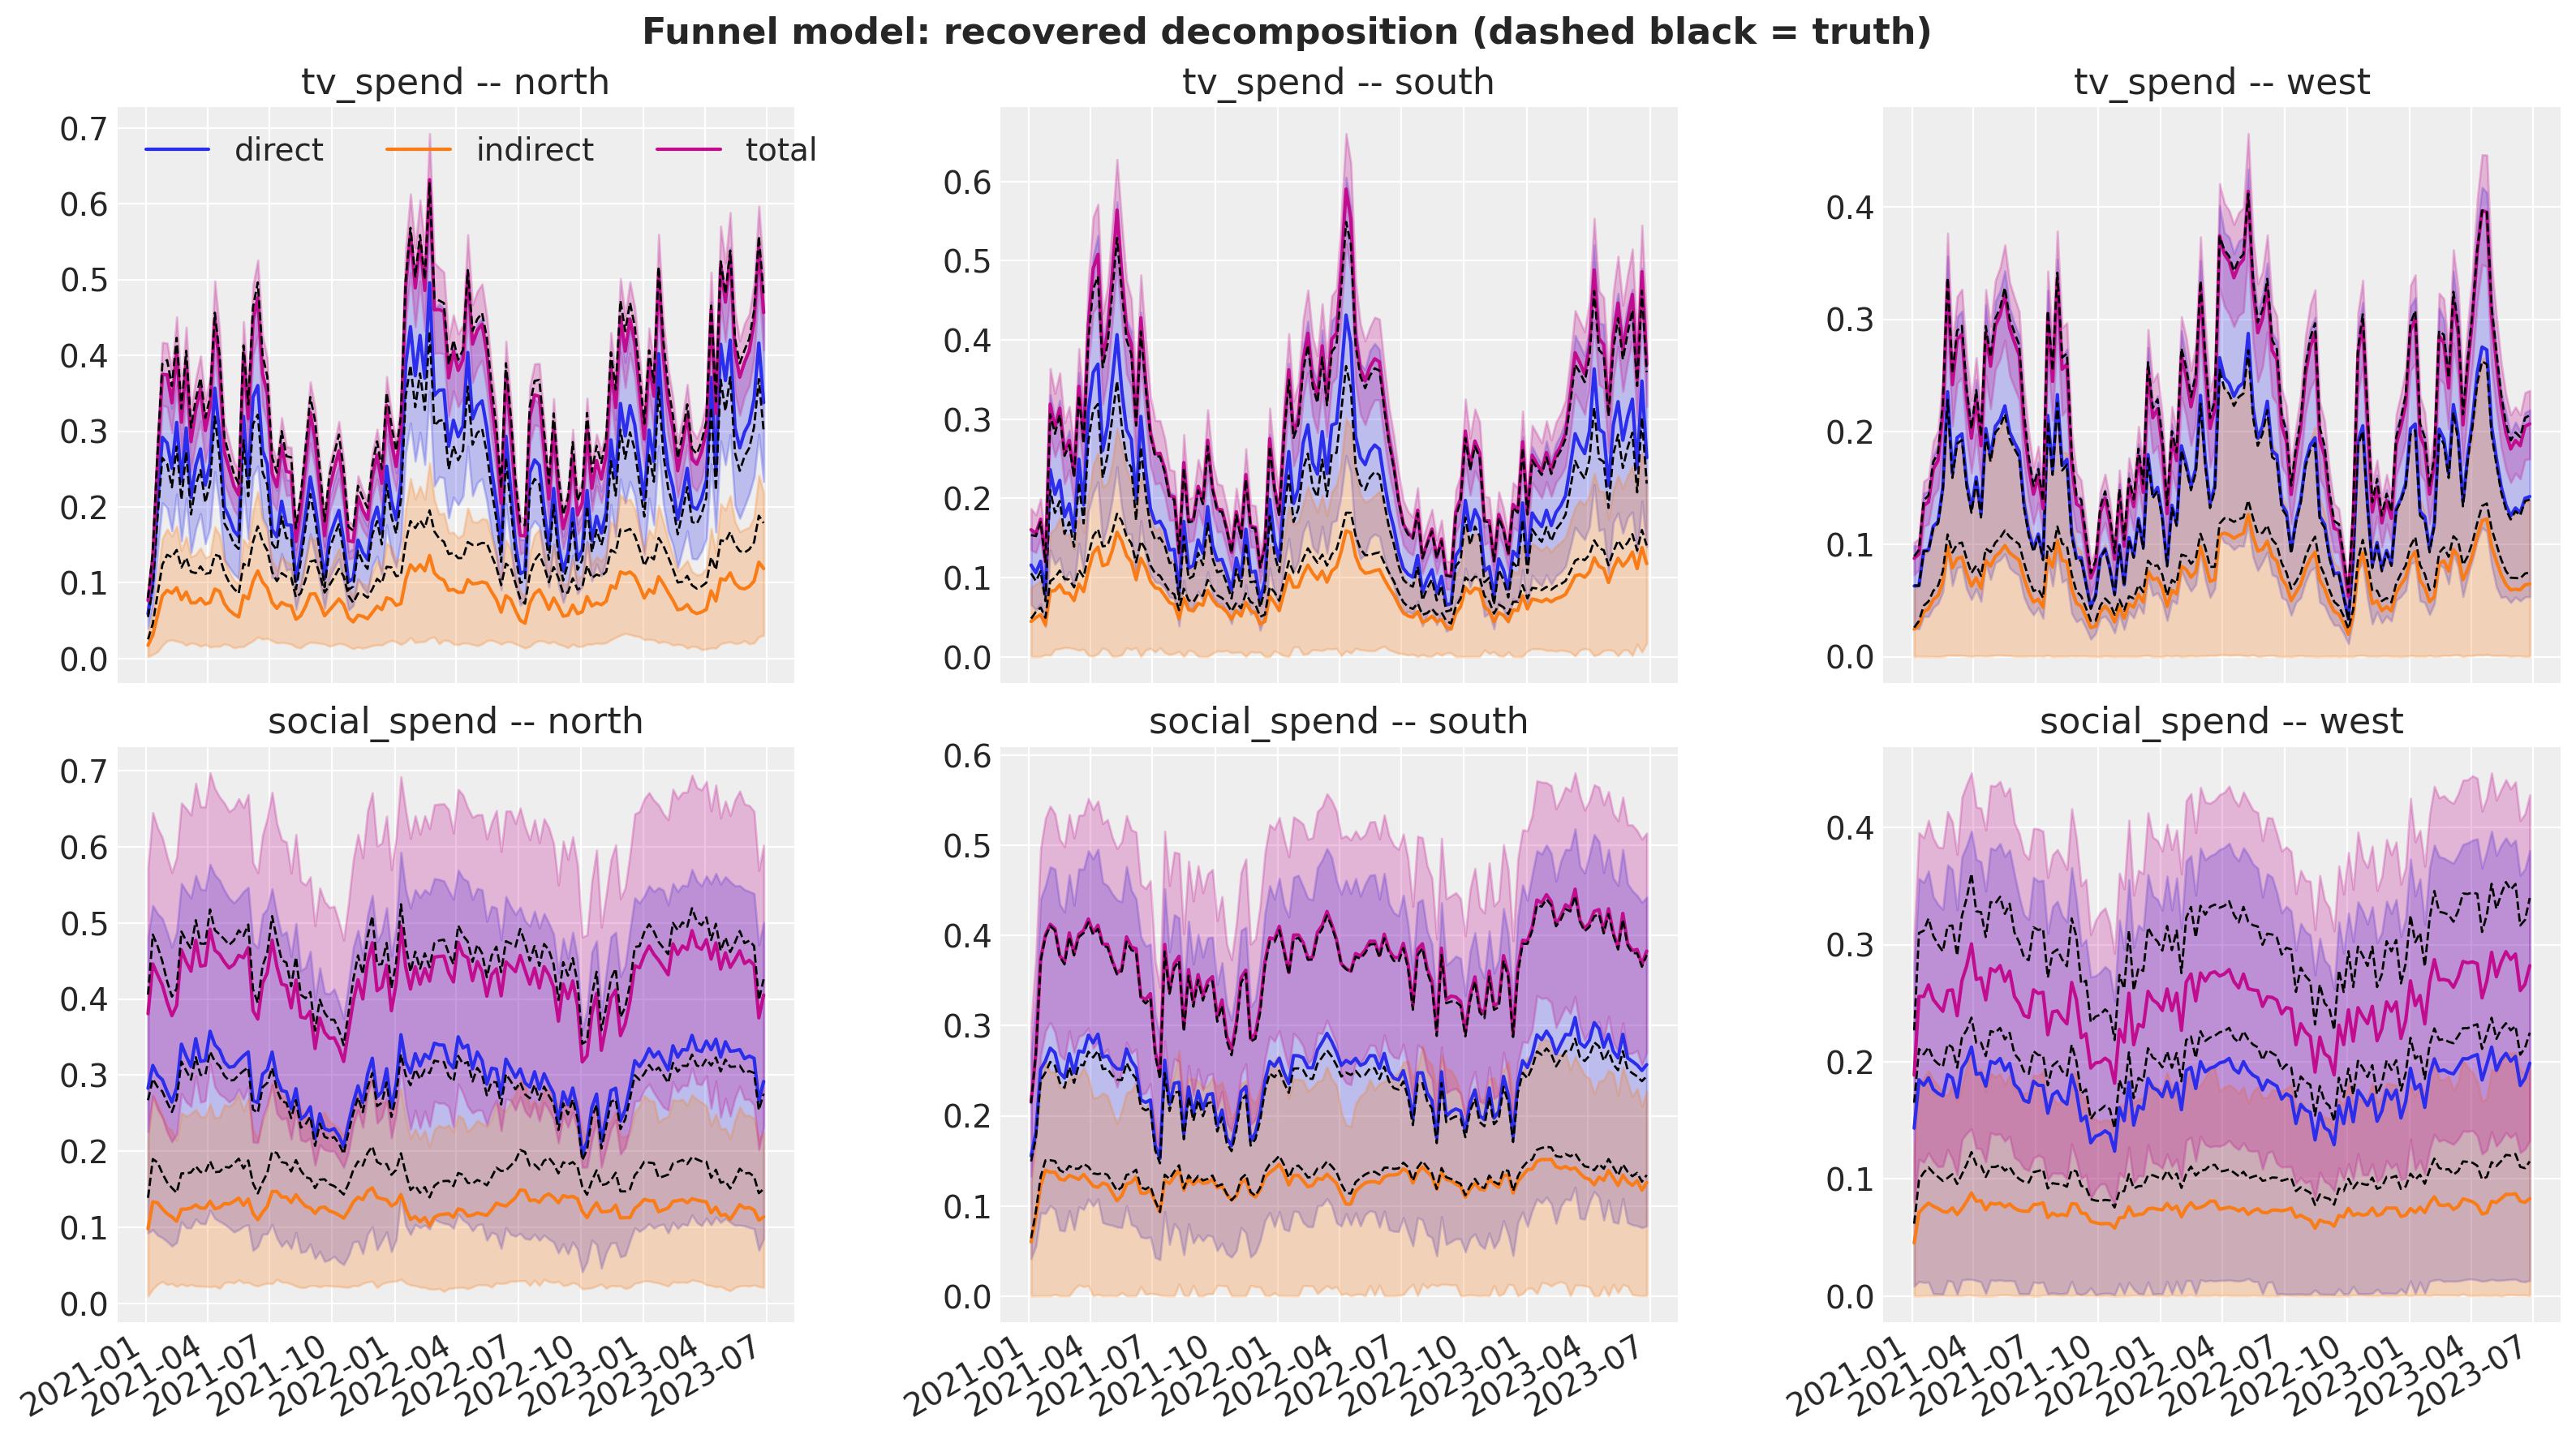

In [28]:
fig, axes = plt.subplots(
    nrows=len(channels), ncols=len(geos), figsize=(16, 9), sharex=True
)
for row, channel in enumerate(channels):
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        for post, truth, label, color in [
            (direct_post, "direct_true", "direct", "C0"),
            (indirect_post, "indirect_true", "indirect", "C1"),
            (total_post, "total_true", "total", "C3"),
        ]:
            sel = post.sel(channel=channel, geo=geo)
            lo, hi = hdi_bounds(sel)
            ax.fill_between(date_range, lo, hi, alpha=0.25, color=color)
            ax.plot(
                date_range, sel.mean(dim=["chain", "draw"]), color=color, label=label
            )
            ax.plot(
                date_range,
                data[truth].sel(channel=channel, geo=geo),
                color="black",
                linestyle="--",
                lw=1,
            )
        ax.set(title=f"{channel} -- {geo}")
axes[0, 0].legend(loc="upper left", ncols=3)
fig.suptitle(
    "Funnel model: recovered decomposition (dashed black = truth)",
    fontsize=16,
    fontweight="bold",
)
fig.autofmt_xdate()
fig.tight_layout()

## Head-to-head: the bias from ignoring the funnel

Finally we compare the three models on the quantity a budget decision actually
turns on -- the **total contribution of each upper-funnel channel**. For the naive
models the channel contribution is already the counterfactual versus zero spend.
For the funnel model we use direct plus the counterfactual indirect effect.

In [29]:
def total_contribution(model: MMM, channel: str) -> xr.DataArray:
    """Mean-over-time total contribution of ``channel`` for a naive model."""
    return (
        model.idata.posterior["channel_contribution_original_scale"]
        .sel(channel=channel)
        .mean(dim="date")
    )


estimates = {
    "Naive A (mediator as channel)": lambda ch: total_contribution(naive_a, ch),
    "Naive B (mediator omitted)": lambda ch: total_contribution(naive_b, ch),
    "Funnel": lambda ch: total_post.sel(channel=ch).mean(dim="date"),
}

truth_mean = data["total_true"].mean("date")

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_77251/2469447302.py:32: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


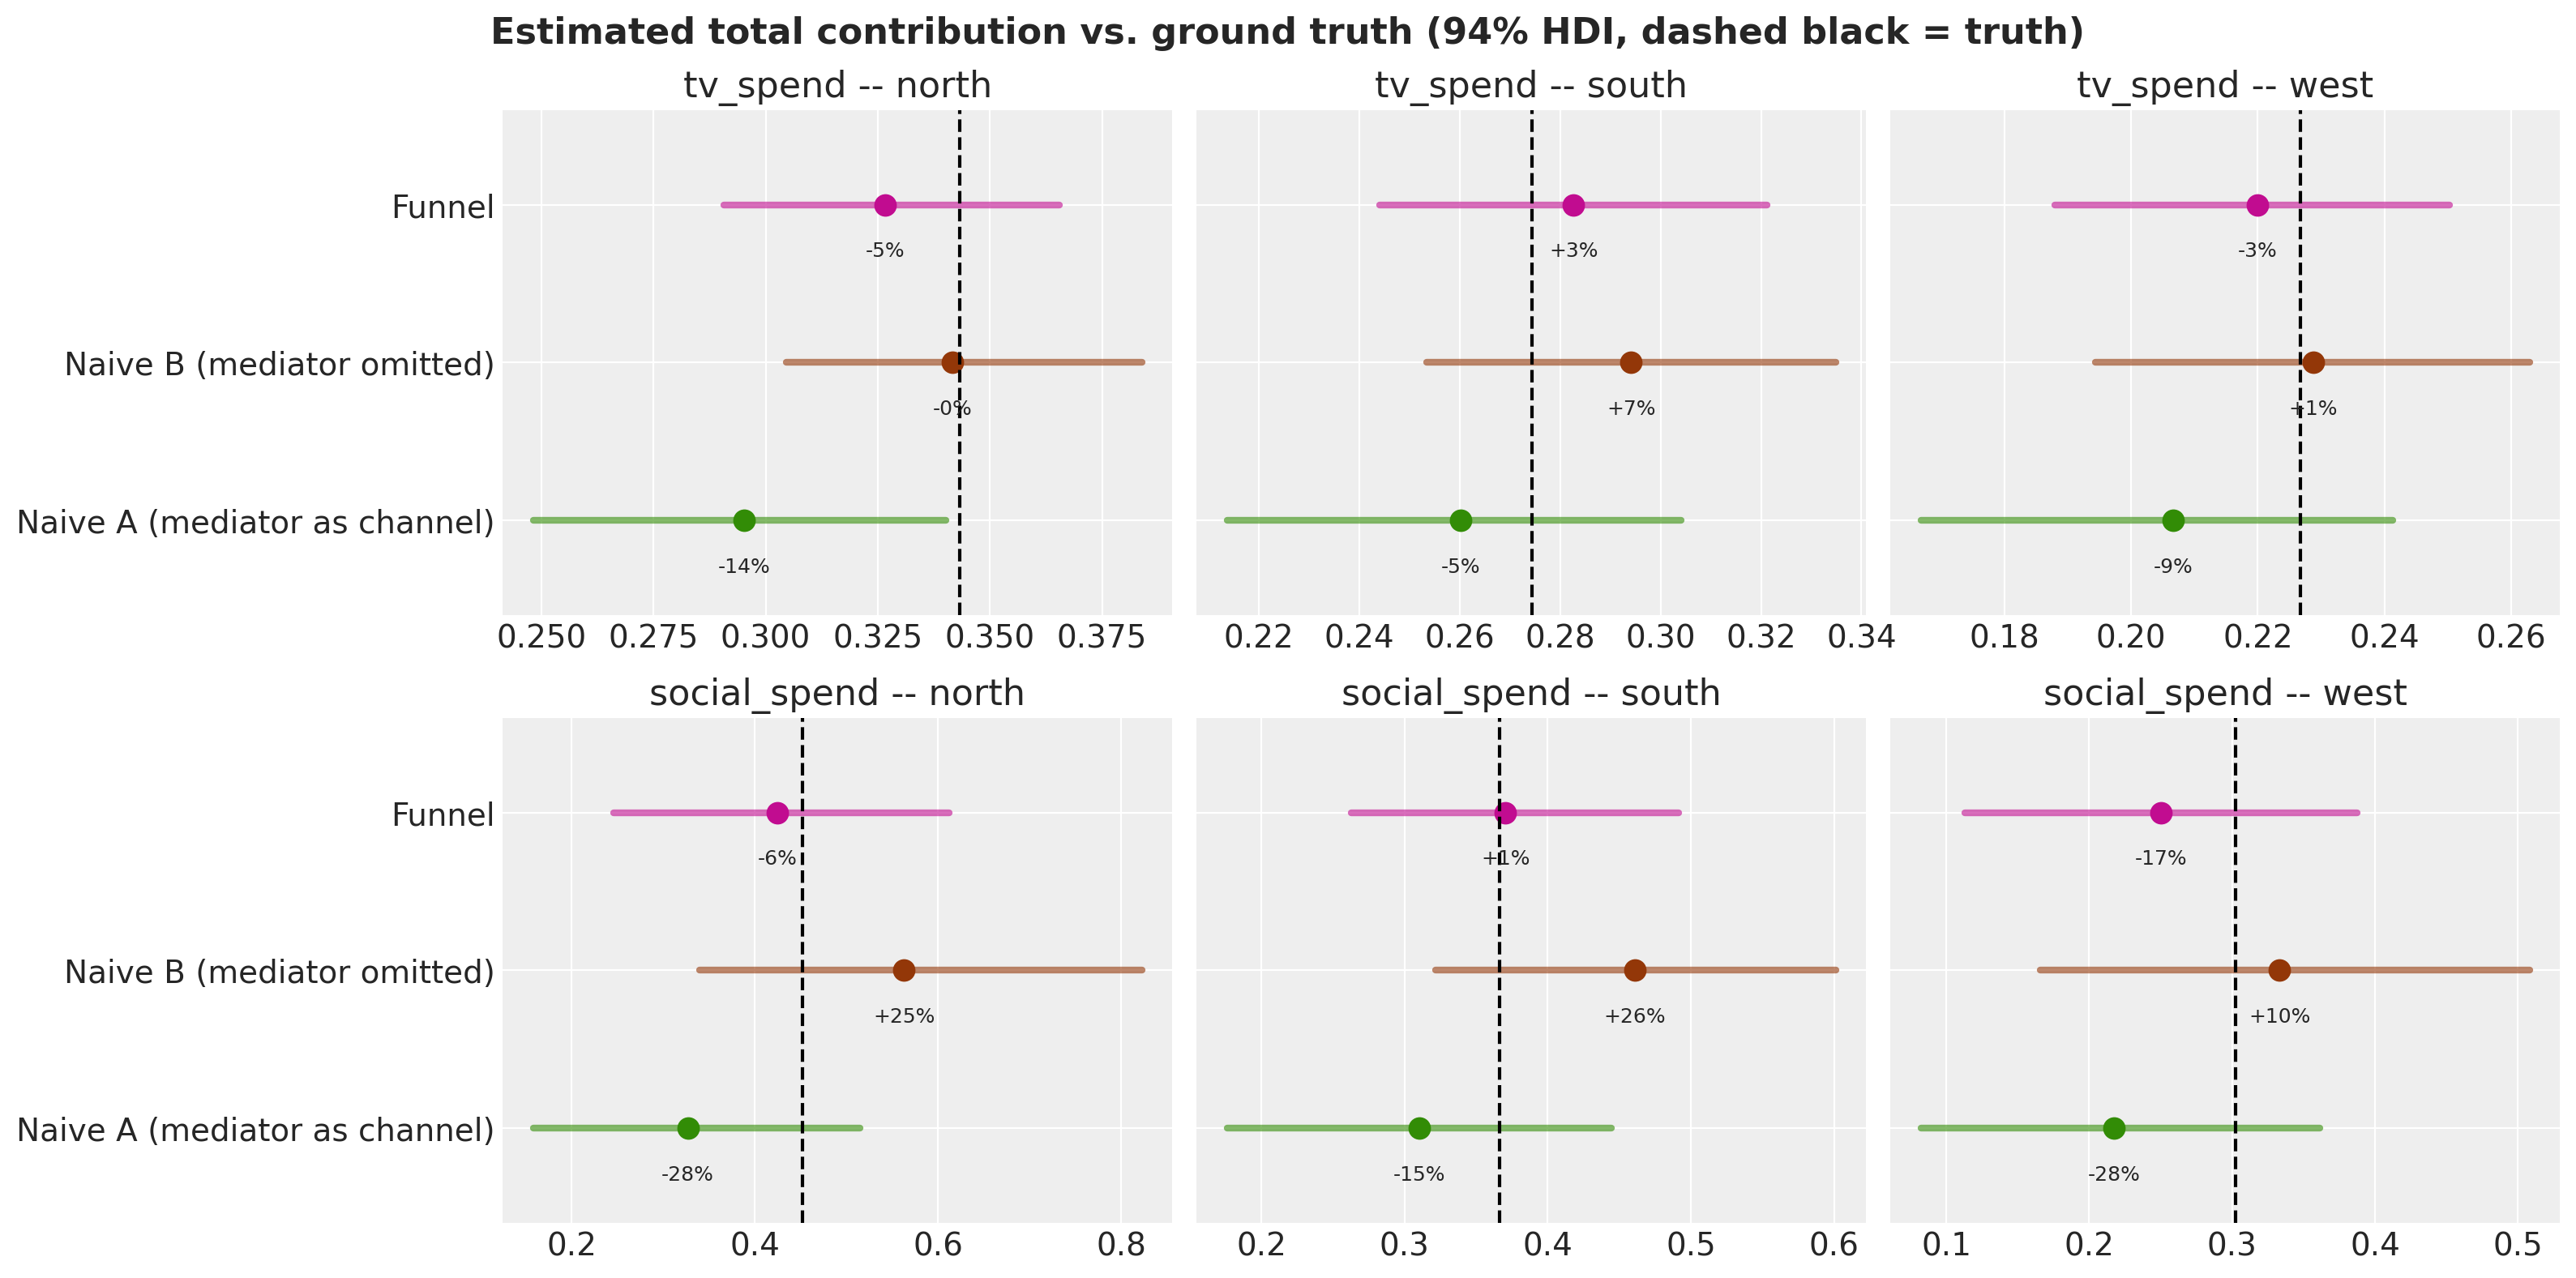

In [30]:
fig, axes = plt.subplots(nrows=len(channels), ncols=len(geos), figsize=(16, 8))
colors = ["C2", "C4", "C3"]
for row, channel in enumerate(channels):
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        truth = float(truth_mean.sel(channel=channel, geo=geo))
        for i, estimate in enumerate(estimates.values()):
            draws = estimate(channel).sel(geo=geo)
            lo, hi = hdi_bounds(draws)
            mean = float(draws.mean())
            ax.plot([float(lo), float(hi)], [i, i], color=colors[i], lw=3, alpha=0.6)
            ax.plot([mean], [i], "o", color=colors[i], ms=9)
            ax.annotate(
                f"{mean / truth - 1:+.0%}",
                (mean, i),
                textcoords="offset points",
                xytext=(0, -16),
                ha="center",
                va="top",
                fontsize=9,
            )
        ax.axvline(truth, color="black", linestyle="--")
        ax.set(title=f"{channel} -- {geo}", yticks=range(len(estimates)))
        ax.set_yticklabels(list(estimates))
        ax.tick_params(labelleft=col == 0)
        ax.margins(y=0.3)
fig.suptitle(
    "Estimated total contribution vs. ground truth (94% HDI, dashed black = truth)",
    fontsize=16,
    fontweight="bold",
)
fig.tight_layout()

Two patterns stand out, and they are different patterns.

**Naive A understates every upper-funnel channel, everywhere.** Putting the
mediator in as a channel conditions on it, which blocks the indirect path by
construction. This bias is systematic and its direction is predictable.

**Naive B's bias is channel-specific.** Omitting the mediator leaves the seasonal,
category-driven part of lower-funnel demand unexplained, and the model hands it to
whichever channel correlates with it. Social spend -- which tracks category demand
closely -- is badly overstated, while TV, which is nearly orthogonal to it, comes
out roughly unbiased. This is the uncomfortable part in practice: the bias from an
omitted mediator is not a uniform shift you could correct with a fudge factor. It
concentrates on the channels whose plans follow demand, which are often exactly
the ones under scrutiny.

The funnel model recovers the totals within its uncertainty in every cell.

We can also express this as a return-on-ad-spend ratio, since that is what budget
allocation keys off. The built-in `incrementality` module runs an on/off
counterfactual on each model's `channel_contribution`.

One subtlety is instructive: that module only sees `channel_contribution`, so for
the funnel model it captures the **direct** path and **misses the mediated one**
-- it does not know the `FunnelEffect` subgraph exists. We therefore report the
funnel model twice: the direct-only ROAS from `incrementality`, and the funnel
**total** ROAS from the counterfactual above.

In [31]:
spend = data[channels].to_array("channel").sum("date")


def incrementality_roas(model: MMM) -> xr.DataArray:
    """All-time ROAS per channel/geo from the incrementality module."""
    return model.incrementality.contribution_over_spend(frequency="all_time").sel(
        channel=channels
    )


roas = {
    "Naive A (mediator as channel)": incrementality_roas(naive_a),
    "Naive B (mediator omitted)": incrementality_roas(naive_b),
    "Funnel (direct only)": incrementality_roas(funnel),
    "Funnel (total)": total_post.sum(dim="date") / spend,
}

true_total_roas = data["total_true"].sum("date") / spend
true_direct_roas = data["direct_true"].sum("date") / spend

In [32]:
roas_summary = pd.DataFrame(
    {
        label: da.mean(dim=["chain", "draw"]).transpose("channel", "geo").to_series()
        for label, da in roas.items()
    }
)
roas_summary["true direct"] = true_direct_roas.transpose("channel", "geo").to_series()
roas_summary["true total"] = true_total_roas.transpose("channel", "geo").to_series()
roas_summary.style.format("{:.3f}")

And the same table as a bias against the true **total** ROAS, for the three
estimates that are meant to represent it:

In [33]:
comparable = [
    "Naive A (mediator as channel)",
    "Naive B (mediator omitted)",
    "Funnel (total)",
]
(roas_summary[comparable].div(roas_summary["true total"], axis=0) - 1).style.format(
    "{:+.1%}"
)

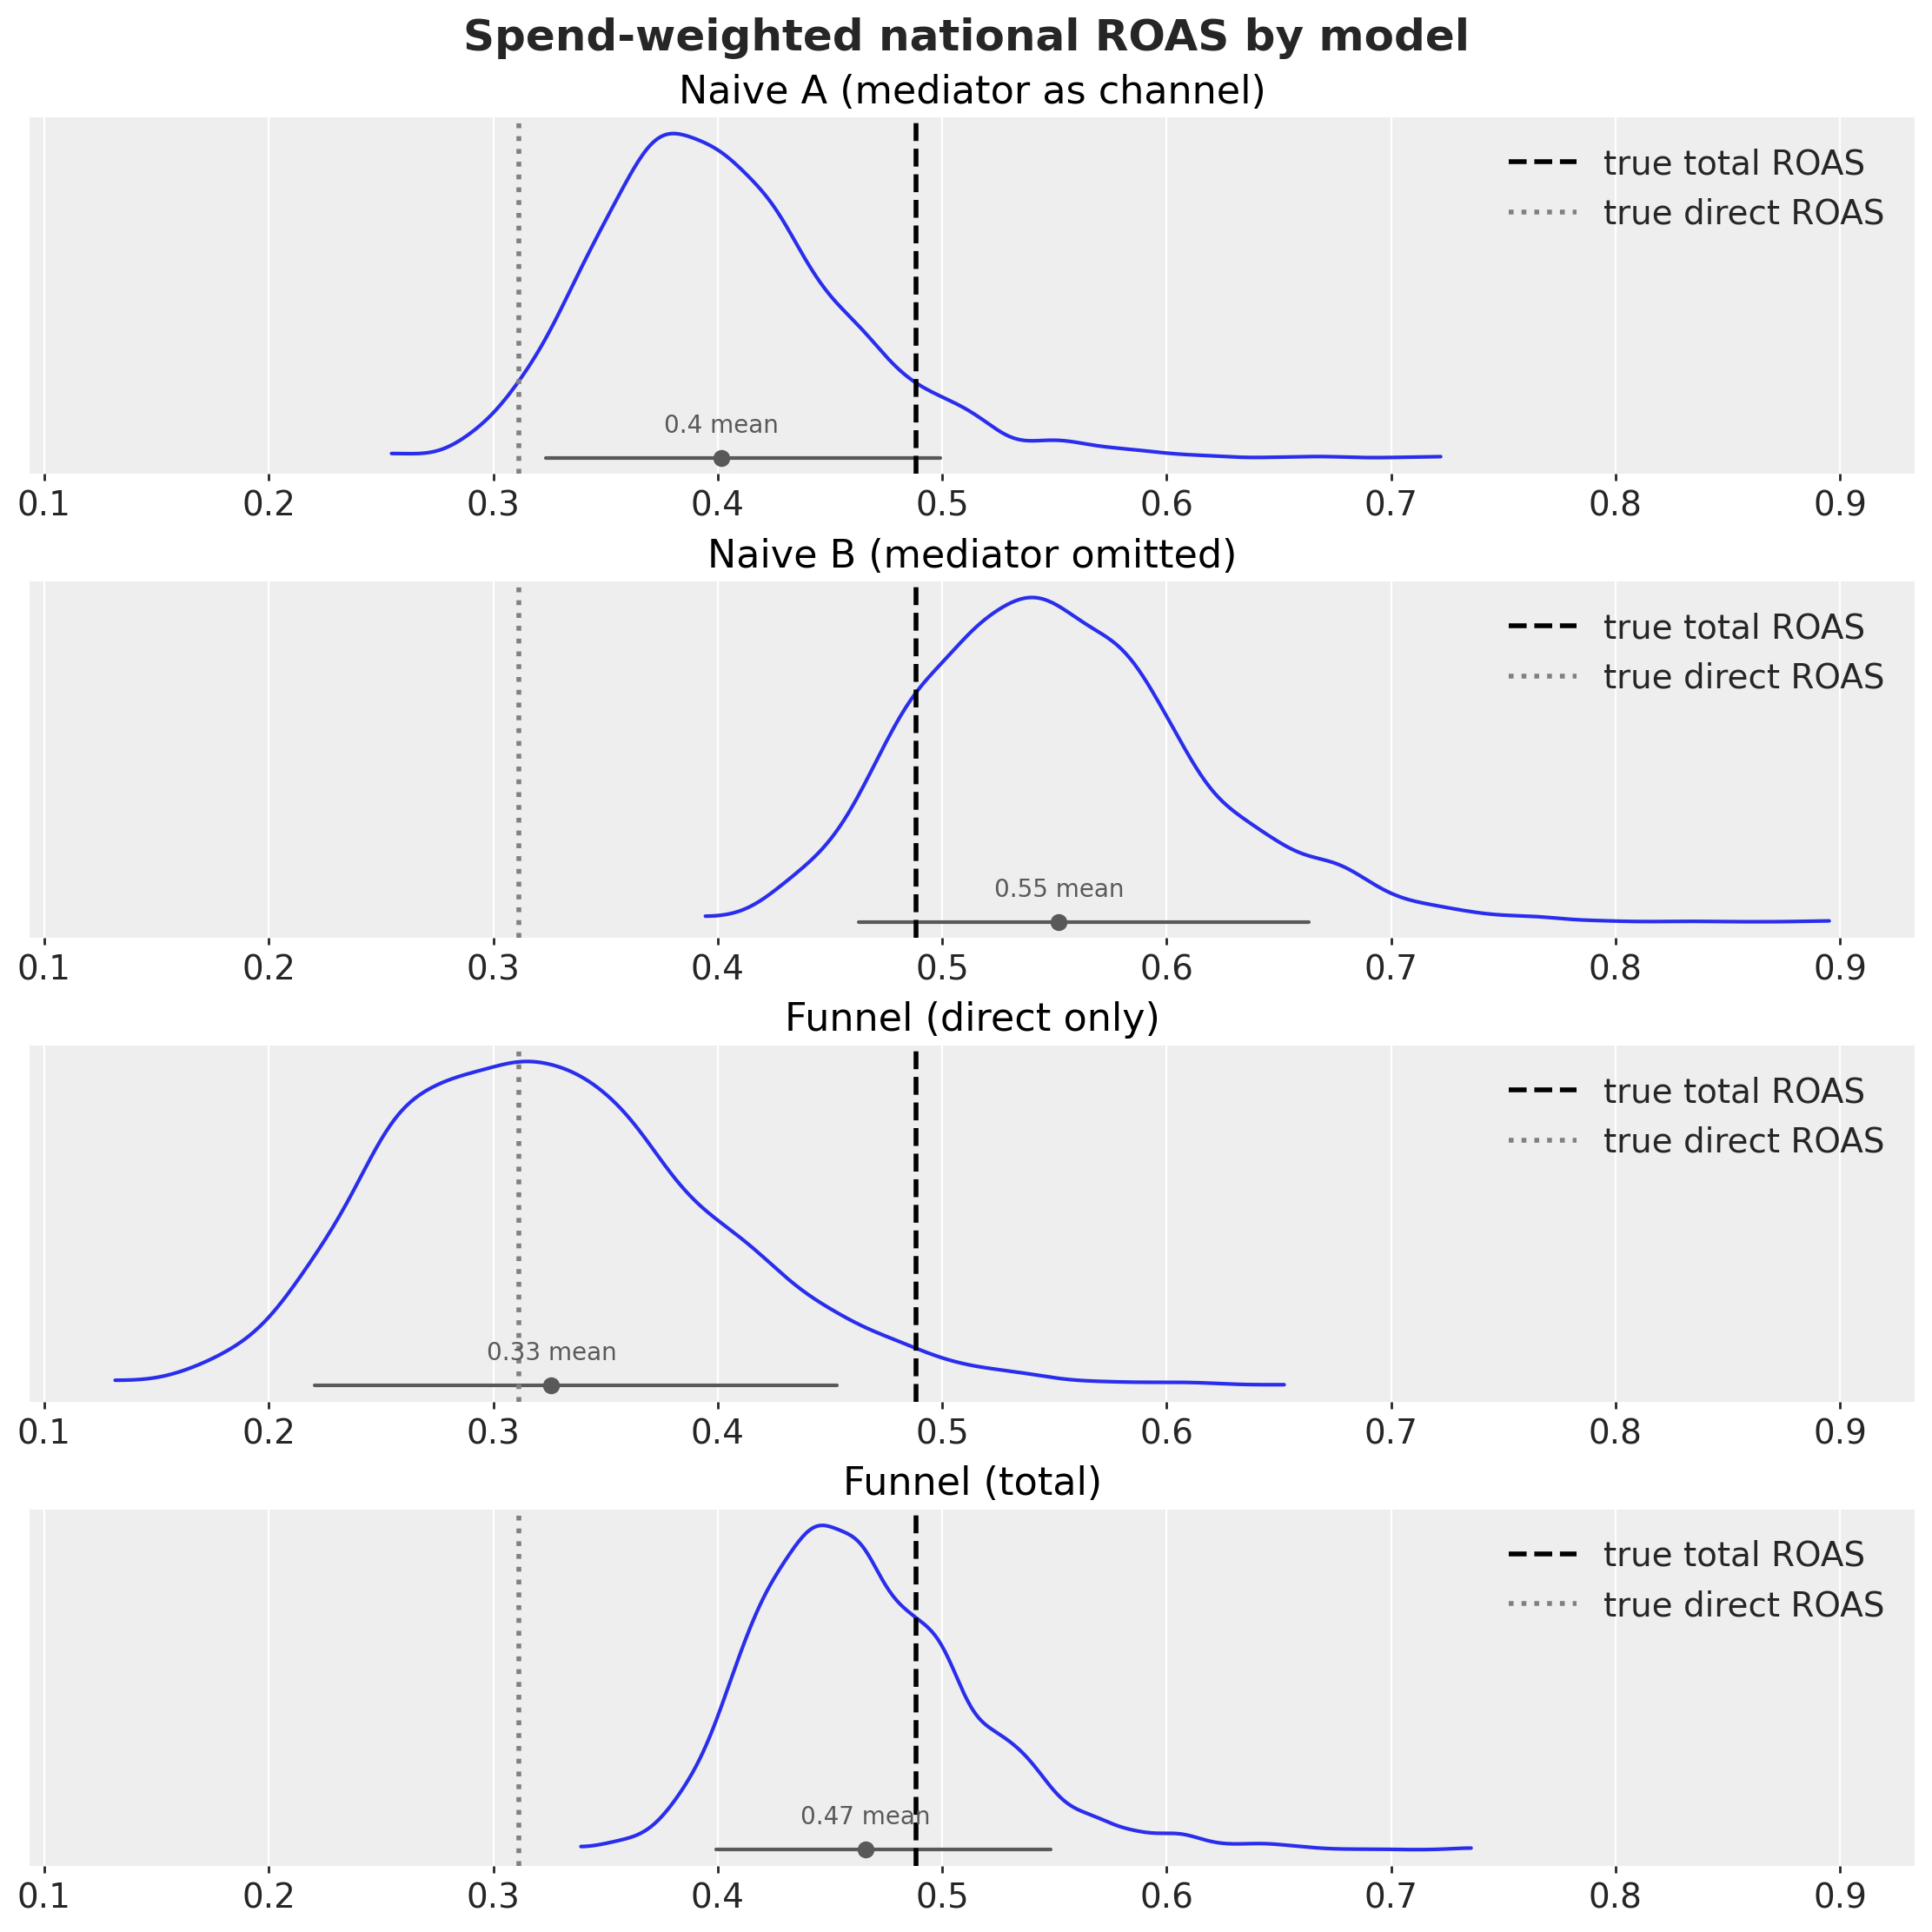

In [34]:
national = {
    label: (da * spend).sum("channel").sum("geo") / spend.sum()
    for label, da in roas.items()
}


def _bare(da):
    """Drop chain/draw coordinate labels so arrays combine positionally."""
    return da.drop_vars([c for c in ("chain", "draw") if c in da.coords])


roas_ds = xr.Dataset({label: _bare(da) for label, da in national.items()})

pc = azp.plot_dist(
    roas_ds,
    col_wrap=1,
    figure_kwargs={
        "figsize": (11, 11),
        "sharex": True,
        "sharey": False,
        "layout": "constrained",
    },
)
fig = pc.viz["/"]["figure"].values.item()
national_true_total = float((true_total_roas * spend).sum() / spend.sum())
national_true_direct = float((true_direct_roas * spend).sum() / spend.sum())
for ax, name in zip(fig.axes, roas_ds.data_vars, strict=True):
    ax.axvline(
        national_true_total,
        color="black",
        linestyle="--",
        linewidth=2,
        label="true total ROAS",
    )
    ax.axvline(
        national_true_direct,
        color="gray",
        linestyle=":",
        linewidth=2,
        label="true direct ROAS",
    )
    ax.set_title(name)
    ax.legend(loc="upper right")
fig.suptitle("Spend-weighted national ROAS by model", fontsize=18, fontweight="bold");

### The bias is invisible in predictive fit

Here is the punchline, and it survives the move to a geo panel. If we judged these
models by how well they fit the target, we would see essentially no difference.
The causal bias does not show up as worse predictive fit, which is exactly why
held-out error alone cannot catch it.

In [35]:
r2 = {}
for label, model in models.items():
    pp = (
        model.idata.posterior_predictive["y"]
        * model.idata.constant_data["target_scale"]
    )
    y_hat = pp.mean(dim=["chain", "draw"])
    y_true, y_hat = xr.align(data["y"], y_hat, join="exact")
    ss_res = float(((y_true - y_hat) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    r2[label] = 1 - ss_res / ss_tot

pd.Series(r2, name="in-sample $R^2$").to_frame().style.format("{:.4f}")

,in-sample $R^2$
Naive A,0.9837
Naive B,0.9832
Funnel,0.9837


## Caveats and extensions

- **The framework does not "see" the DAG.** The funnel structure lives in the
  `FunnelEffect` code. To the `MMM` object, `funnel_effect_contribution` is one
  more additive term, and the built-in contribution and ROAS helpers treat it as a
  flat direct effect unless you post-process it, as we did here.
- **Pass a `Dataset`, not a `DataFrame`.** Extra columns in a DataFrame are
  dropped during conversion, so a `DataVarMuEffect` would not find its variables.
  Build the model from an `xarray.Dataset`; `fit` still takes the long frame for
  its bookkeeping.
- **Pooling choices are identification choices.** We pooled carryover and
  curvature across geos and left amplitudes free. Freeing everything per geo with
  ~130 weeks each will widen the posteriors considerably and can introduce
  divergences; hierarchical (partially pooled) priors are the natural next step.
- **Latent variables need an anchor.** Fixing the lower-funnel spend loading at
  one is what gives $D$ a scale. If both loadings were free, the model would be
  unidentified. Which indicator you anchor to is a substantive choice: it defines
  the units in which "demand" is expressed.
- **Per-channel indirect effects are not additive.** With a shared saturating
  mediator, leave-one-out attribution understates the joint effect -- here by about
  10%. Report the convention alongside the number.
- **Mind the scales.** The base `MMM` scales its channel and target data, but a
  `DataVarMuEffect` reads its variables **unscaled**. Here the data is generated
  in-model at roughly unit scale, so the `HalfNormal(1)` priors in the demand
  equation are sensible. On real data, scale those inputs (or the priors) yourself.
- **Budget optimization.** `BudgetOptimizer` does not substitute its decision
  variables into `MuEffect` subgraphs, so funnel-aware optimization is still out of
  scope.

Natural extensions: hierarchical priors across geos, **censored** lower-funnel
spend for budget-capped channels, more than one latent demand pool (for example
separate branded and non-branded demand), and time-varying mediator baselines.

In [36]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Tue, 28 Jul 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.14.0

pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7

arviz         : 1.2.0
arviz_plots   : 1.2.0
graphviz      : 0.21
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

